# Notebook 04 — HHI Concentration Analysis (Equation 1)
### Thesis: *BRICS Currencies and Global Monetary Fragmentation: An Empirical Analysis of Local Currency Settlement in International Trade (2010–2025)*
**Aadhitya Tejaswin Prakash Sridevi | EDHEC Business School / University of St. Gallen (HSG)**

---

## 1. Purpose of This Notebook

This notebook implements **Equation 1** of the empirical strategy: the Herfindahl-Hirschman Index (HHI) Concentration Analysis. It is the descriptive-analytical foundation of the thesis. Before testing causal relationships (Equations 2 and 3), Equation 1 establishes the empirical baseline: *how concentrated is the global currency system, has that concentration changed between 2010 and 2025, and where does CNY fit in that trajectory?*

The notebook does not estimate a regression. It computes, visualises, and interprets the evolution of currency concentration across two complementary dimensions — payments and reserves — and tracks the CNY internationalisation arc as the central BRICS currency of interest.

---

## 2. The Economic Question

The thesis is grounded in Gopinath's **Dominant Currency Paradigm (DCP)**, which holds that a small number of currencies — principally the US Dollar — invoice and settle the large majority of global trade regardless of who the bilateral trading partners are. DCP predicts that currency concentration in payments and reserves should be persistent, with USD dominance self-reinforcing through network externalities, financial depth, and institutional trust.

**Equation 1 asks: is that concentration actually stable, and if not, what is driving the change?**

Three possible narratives are in tension in the data:

- **DCP persistence:** USD concentration reasserts itself after shocks, CNY gains are marginal and cyclical, the system remains fundamentally unipolar.
- **Gradual fragmentation:** CNY share in both payments and reserves rises slowly but structurally, consistent with a long-run shift toward multipolarity driven by China's trade and financial integration.
- **Shock-driven fragmentation:** The Russia SWIFT exclusion (February 2022) was a discrete geopolitical shock that accelerated de-dollarisation within specific bilateral corridors, but the aggregate system proved resilient — USD concentration actually *increased* in the immediate post-sanctions period.

The data — and the HHI — allows us to distinguish between these narratives empirically.

---

## 3. The Equation

The Herfindahl-Hirschman Index is defined as:

$$HHI_t = \sum_{i} \left(\frac{s_{i,t}}{100}\right)^2$$

where $s_{i,t}$ is the share of currency $i$ in year $t$, expressed in percentage points. The index ranges from 0 (perfectly dispersed) to 1 (complete monopoly). A higher HHI indicates greater concentration — i.e., fewer currencies dominating the system.

This is computed across **two dimensions**:

**Dimension A — Payment currencies (SWIFT):**
Currency shares from the SWIFT Global Currency Tracker annual series. Currencies included: USD, EUR, GBP, JPY, CNY, CAD, Others. The HHI is pre-computed in `SWIFT_HHI_Annual_Clean.csv` and verified here.

**Dimension B — Reserve currencies (COFER):**
Currency shares from IMF COFER annual data. Currencies included: USD, EUR, GBP, JPY, CNY, CAD, AUD, CHF, OTHER. The HHI is computed from scratch in this notebook, as COFER provides a richer currency breakdown.

The two dimensions are **conceptually distinct but empirically related**: payment concentration reflects the transactional role of currencies in trade and finance; reserve concentration reflects the store-of-value and safe-asset role. DCP predicts they should co-move, with USD dominant in both. A divergence between the two would be theoretically significant.

---

## 4. Datasets Used

| Dataset | File | Rows | Role in This Notebook |
|---|---|---|---|
| SWIFT HHI Annual | `SWIFT_HHI_Annual_Clean.csv` | 13 | Primary source for Dimension A (payments HHI). Annual currency shares 2013–2025. HHI pre-computed. |
| IMF COFER Annual | `IMF_COFER_Clean.csv` | 16 | Primary source for Dimension B (reserves HHI). Annual reserve shares 2010–2025. HHI computed here. |
| SWIFT Monthly CNY | `SWIFT_RMB_Monthly_Clean.csv` | 86 | High-frequency CNY share series January 2019 – February 2026. Used for CNY internationalisation arc plot. |

No data from `Master_Panel_BRICS_2010_2024.csv` is used here. Equation 1 operates at the **global system level**, not the bilateral pair level. The bilateral panel is the unit of analysis for Equations 2 and 3.

---

## 5. Known Data Constraints and Handling

These are not weaknesses to hide — they are documented methodological decisions that strengthen the integrity of the analysis.

| Issue | Handling |
|---|---|
| **SWIFT HHI 2021 missing** | HHI = NaN. CNY = 2.70% retained. Not interpolated. Shown as a gap in all plots. Treated as a structural break year: COVID-19 recovery volatility and proximity to the February 2022 Russia sanctions shock make interpolation methodologically inappropriate. |
| **SWIFT HHI 2013 approximate** | Sourced from a low-resolution Wayback Machine archive image. Retained but flagged with annotation in all plots. |
| **COFER CNY 2010–2015: NaN** | China's RMB was not separately reported in COFER before joining the IMF SDR basket in October 2016. These are true structural NaNs, not missing data — they reflect an institutional fact. Not backfilled. |
| **COFER 2016: flag_cny_partial** | Only Q4 2016 data available for CNY (SDR inclusion mid-year). Annual mean based on one quarter. Annotated in plots. |
| **COFER 2025: flag_partial_year** | Q1–Q3 only. Annual mean based on three quarters. Annotated in plots. |
| **COFER CAD/AUD: NaN 2010–2011** | These currencies were not separately broken out in early COFER reporting. When computing COFER HHI for those years, only available currency columns are summed — shares may not sum to 100%, and HHI will be noted as approximate. |
| **SWIFT undercounts CIPS/SPFS** | Payments routed through China's CIPS system and Russia's SPFS fall outside SWIFT's measurement perimeter. The SWIFT-based CNY share is therefore a lower bound on actual CNY settlement activity. This limitation is stated explicitly in the methodology chapter. |

---

## 6. Outputs Produced

All plots saved to `outputs/` at 150 DPI.

| Output | Filename | Description |
|---|---|---|
| Plot 1 | `hhi_swift_currency_shares.png` | SWIFT HHI time series (2013–2025) with USD, EUR, CNY, GBP shares on the same axes. 2021 gap and 2022 sanctions line annotated. |
| Plot 2 | `hhi_cofer_currency_shares.png` | COFER HHI time series (2010–2025) with USD, EUR, CNY shares. 2022 sanctions line annotated. CNY pre-2016 NaN gap shown. |
| Plot 3 | `hhi_swift_vs_cofer.png` | Side-by-side dual-series plot: SWIFT HHI vs COFER HHI on the same figure. Tests whether both dimensions show the same post-2022 USD reassertion. |
| Plot 4 | `cny_internationalisation_arc.png` | Dual-axis plot: SWIFT monthly CNY share (Jan 2019 – Feb 2026) overlaid with COFER annual CNY share (2016–2025). Peak, trough, and post-2022 reversal annotated. |
| Plot 5 | `swift_currency_decomposition.png` | Stacked area chart of SWIFT currency shares 2013–2025. Shows compositional shift over time. |
| Table 1 | Displayed inline | Pre-2022 vs post-2022 means for SWIFT HHI, COFER HHI, USD share (both), CNY share (both). |

---

## 7. Key Empirical Signals to Watch For

These are the patterns already visible in the cleaned data that this notebook will formalise and visualise:

- **SWIFT HHI 2022 spike:** HHI rises to 0.316 in 2022, the highest in the sample, versus a pre-sanctions mean of approximately 0.300. This is the central Equation 1 finding: the Russia SWIFT exclusion *reasserted* USD dominance in aggregate payment flows, the opposite of what a simple de-dollarisation narrative would predict.
- **Post-2022 partial reversion:** SWIFT HHI declines to 0.299 by 2024–2025, but remains above the pre-2019 baseline. Whether this reversion is structural or cyclical is a key interpretive question.
- **CNY peak and reversal:** CNY SWIFT share peaks at 4.74% in July 2024 (monthly) and 4.61% in 2023 (annual). COFER CNY peaks at approximately 2.70% in 2021–2022. Both series show post-peak decline. This directly engages the sceptical literature: CNY internationalisation appears to have stalled, not accelerated, in the post-sanctions period.
- **USD COFER decline is slow and steady:** USD reserve share falls from 62.0% (2010) to 57.5% (2025) — a 4.5 percentage point decline over 15 years. This is gradual erosion, not collapse, consistent with DCP's prediction of persistence.
- **The two HHI dimensions may diverge:** SWIFT HHI spikes in 2022; COFER HHI does not show the same spike. If confirmed, this divergence would suggest that the sanctions shock was a payments-layer event, not a reserve-preference event — a theoretically important distinction.

---

## 8. Connection to Equations 2 and 3

Equation 1 is purely descriptive. It documents the system-level trajectory. Equations 2 and 3 then ask the causal question at the bilateral level:

- **Equation 2** asks what bilateral-level factors (trade intensity, FX volatility, GDP, institutional linkages) explain cross-sectional variation in local currency settlement share (LCShare) across BRICS country pairs.
- **Equation 3** asks whether specific policy events — particularly the Russia SWIFT exclusion — caused a measurable shift in LCShare in the treated bilateral corridors, using a Difference-in-Differences design.

The HHI findings from this notebook provide the aggregate backdrop against which the bilateral results of Equations 2 and 3 should be interpreted. If the system-level HHI shows USD reassertion post-2022, but the DiD in Equation 3 finds a positive treatment effect on LCShare in Russia-China bilateral trade, this is not a contradiction — it reflects the distinction between aggregate system resilience and corridor-specific re-routing. That distinction is one of the thesis's core empirical contributions.

---
*Notebook: `04_hhi_analysis.ipynb` | Upstream: `02_data_cleaning.ipynb` (commit `9eecc92`), `03_panel_construction.ipynb` (commit `d615189`) | Last updated: May 2026*

In [1]:
# Cell 1 — Setup and imports
# 04_hhi_analysis.ipynb | Equation 1: HHI Concentration Analysis
# Thesis: BRICS Currencies and Global Monetary Fragmentation (2010–2025)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
OUTPUTS = '/Users/psat0501/Desktop/HSG/Master Thesis/Master_Thesis_Brics_Currencies/outputs/'

# ── Plot styling ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'font.family':       'serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

# ── Colour palette (thesis-consistent across all notebooks) ───────────────────
COLORS = {
    'USD':       '#1f4e79',   # deep blue
    'EUR':       '#2e75b6',   # medium blue
    'GBP':       '#70ad47',   # green
    'JPY':       '#ed7d31',   # orange
    'CNY':       '#c00000',   # red  — CNY is the focal currency throughout
    'CAD':       '#7030a0',   # purple
    'Others':    '#a5a5a5',   # grey
    'AUD':       '#ffc000',   # amber
    'CHF':       '#4472c4',   # cornflower blue
    'OTHER':     '#bfbfbf',   # light grey
    'HHI_swift': '#1f4e79',   # deep blue — SWIFT HHI line
    'HHI_cofer': '#c00000',   # red       — COFER HHI line
    'sanctions': '#ff0000',   # sanctions event line
    'approx':    '#ed7d31',   # approximate data annotation
}

# ── Sanctions event reference year ────────────────────────────────────────────
SANCTIONS_YEAR = 2022

print("Libraries loaded successfully.")
print(f"  matplotlib : {matplotlib.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  Output path: {OUTPUTS}")

Libraries loaded successfully.
  matplotlib : 3.9.4
  pandas     : 2.3.3
  numpy      : 2.0.2
  Output path: /Users/psat0501/Desktop/HSG/Master Thesis/Master_Thesis_Brics_Currencies/outputs/


In [2]:
# Cell 2 — Data loading and structural validation

# ── Load all three input files ─────────────────────────────────────────────────
swift_hhi  = pd.read_csv(OUTPUTS + 'SWIFT_HHI_Annual_Clean.csv')
cofer      = pd.read_csv(OUTPUTS + 'IMF_COFER_Clean.csv')
swift_rmb  = pd.read_csv(OUTPUTS + 'SWIFT_RMB_Monthly_Clean.csv', parse_dates=['Date'])

# ── SWIFT HHI — structural check ──────────────────────────────────────────────
print("=" * 60)
print("SWIFT_HHI_Annual_Clean.csv")
print("=" * 60)
print(f"  Shape         : {swift_hhi.shape}")
print(f"  Years         : {swift_hhi['Year'].min()} – {swift_hhi['Year'].max()}")
print(f"  HHI range     : {swift_hhi['HHI'].min():.4f} – {swift_hhi['HHI'].max():.4f}")
print(f"  flag_missing  : {swift_hhi['flag_missing'].sum()} row(s)  "
      f"[year(s): {swift_hhi.loc[swift_hhi['flag_missing']==True, 'Year'].tolist()}]")
print(f"  flag_approx   : {swift_hhi['flag_approximate'].sum()} row(s)  "
      f"[year(s): {swift_hhi.loc[swift_hhi['flag_approximate']==True, 'Year'].tolist()}]")
print(f"  HHI NaN count : {swift_hhi['HHI'].isna().sum()} (expected: 1 — year 2021)")
print()

# ── IMF COFER — structural check ──────────────────────────────────────────────
print("=" * 60)
print("IMF_COFER_Clean.csv")
print("=" * 60)
print(f"  Shape              : {cofer.shape}")
print(f"  Years              : {cofer['Year'].min()} – {cofer['Year'].max()}")
print(f"  flag_cny_partial   : {cofer['flag_cny_partial'].sum()} row(s)  "
      f"[year(s): {cofer.loc[cofer['flag_cny_partial']==True, 'Year'].tolist()}]")
print(f"  flag_partial_year  : {cofer['flag_partial_year'].sum()} row(s)  "
      f"[year(s): {cofer.loc[cofer['flag_partial_year']==True, 'Year'].tolist()}]")
print(f"  CNY NaN years      : {cofer.loc[cofer['CNY'].isna(), 'Year'].tolist()} (expected: 2010–2015)")
print()

# ── SWIFT Monthly CNY — structural check ──────────────────────────────────────
print("=" * 60)
print("SWIFT_RMB_Monthly_Clean.csv")
print("=" * 60)
print(f"  Shape         : {swift_rmb.shape}")
print(f"  Date range    : {swift_rmb['Date'].min().strftime('%b %Y')} – "
      f"{swift_rmb['Date'].max().strftime('%b %Y')}")
print(f"  Missing values: {swift_rmb['RMB_Share_Pct'].isna().sum()} (expected: 0)")
print(f"  Peak CNY share: {swift_rmb['RMB_Share_Pct'].max():.2f}%  "
      f"({swift_rmb.loc[swift_rmb['RMB_Share_Pct'].idxmax(), 'Date'].strftime('%b %Y')})")
print(f"  Trough CNY    : {swift_rmb['RMB_Share_Pct'].min():.2f}%  "
      f"({swift_rmb.loc[swift_rmb['RMB_Share_Pct'].idxmin(), 'Date'].strftime('%b %Y')})")
print()

# ── Share row-sum check for SWIFT HHI (complete years only) ───────────────────
swift_complete = swift_hhi[swift_hhi['flag_missing'] == False].copy()
share_cols_swift = ['USD', 'EUR', 'GBP', 'JPY', 'CNY', 'CAD', 'Others']
swift_complete['row_sum'] = swift_complete[share_cols_swift].sum(axis=1)
sum_ok = swift_complete['row_sum'].between(99.5, 100.5).all()
print(f"SWIFT share row sums (complete years): "
      f"{'OK — all within 99.5–100.5%' if sum_ok else 'WARNING — check row sums'}")
print(swift_complete[['Year', 'row_sum']].to_string(index=False))

SWIFT_HHI_Annual_Clean.csv
  Shape         : (13, 12)
  Years         : 2013 – 2025
  HHI range     : 0.2917 – 0.3160
  flag_missing  : 1 row(s)  [year(s): [2021]]
  flag_approx   : 1 row(s)  [year(s): [2013]]
  HHI NaN count : 1 (expected: 1 — year 2021)

IMF_COFER_Clean.csv
  Shape              : (16, 12)
  Years              : 2010 – 2025
  flag_cny_partial   : 1 row(s)  [year(s): [2016]]
  flag_partial_year  : 1 row(s)  [year(s): [2025]]
  CNY NaN years      : [2010, 2011, 2012, 2013, 2014, 2015] (expected: 2010–2015)

SWIFT_RMB_Monthly_Clean.csv
  Shape         : (86, 4)
  Date range    : Jan 2019 – Feb 2026
  Missing values: 0 (expected: 0)
  Peak CNY share: 4.74%  (Jul 2024)
  Trough CNY    : 1.65%  (Oct 2019)

SWIFT share row sums (complete years): OK — all within 99.5–100.5%
 Year  row_sum
 2013    100.0
 2014    100.0
 2015    100.0
 2016    100.0
 2017    100.0
 2018    100.0
 2019    100.0
 2020    100.0
 2022    100.0
 2023    100.0
 2024    100.0
 2025    100.0


In [3]:
# Cell 3 — Compute COFER HHI from annual reserve shares

# COFER provides a richer currency breakdown than SWIFT (9 currencies vs 7).
# HHI is not pre-computed in the cleaned file — we compute it here from scratch.
# Formula: HHI_t = Σ (share_i / 100)²
# Only sum over columns with non-NaN values for a given year.
# CAD and AUD are NaN for 2010–2011 — HHI for those years is flagged approximate.

cofer_share_cols = ['USD', 'EUR', 'GBP', 'JPY', 'CNY', 'CAD', 'AUD', 'CHF', 'OTHER']

# ── Compute HHI row by row ─────────────────────────────────────────────────────
def compute_hhi(row, cols):
    """Sum of squared shares for non-NaN columns. Returns (hhi, n_currencies_used)."""
    vals = row[cols].dropna()
    hhi  = ((vals / 100) ** 2).sum()
    return pd.Series({'HHI_cofer': hhi, 'n_currencies': len(vals)})

cofer[['HHI_cofer', 'n_currencies']] = cofer.apply(
    compute_hhi, axis=1, cols=cofer_share_cols
)

# ── Flag years where not all currencies were available ────────────────────────
# 2010–2011: CAD and AUD not separately reported → HHI computed on 7 currencies
# 2010–2015: CNY not separately reported → included in OTHER
cofer['flag_hhi_approximate'] = cofer['n_currencies'] < len(cofer_share_cols)

# ── Row sum check for COFER (to verify shares are internally consistent) ──────
cofer['row_sum'] = cofer[cofer_share_cols].sum(axis=1, min_count=1)

# ── Display results ───────────────────────────────────────────────────────────
print("COFER HHI computed successfully.")
print()
print(cofer[['Year', 'USD', 'EUR', 'CNY', 'HHI_cofer',
             'n_currencies', 'flag_hhi_approximate',
             'flag_cny_partial', 'flag_partial_year',
             'row_sum']].to_string(index=False))
print()
print(f"COFER HHI range : {cofer['HHI_cofer'].min():.4f} – {cofer['HHI_cofer'].max():.4f}")
print(f"Approximate HHI years (fewer than {len(cofer_share_cols)} currencies): "
      f"{cofer.loc[cofer['flag_hhi_approximate'], 'Year'].tolist()}")

COFER HHI computed successfully.

 Year       USD       EUR      CNY  HHI_cofer  n_currencies  flag_hhi_approximate  flag_cny_partial  flag_partial_year    row_sum
 2010 62.026775 23.256425      NaN   0.445999           6.0                  True             False              False 100.000000
 2011 62.031650 22.395000      NaN   0.443089           6.0                  True             False              False 100.000000
 2012 61.918025 21.598750      NaN   0.438679           8.0                  True             False              False 102.825800
 2013 61.893850 21.236650      NaN   0.434257           8.0                  True             False              False  99.999975
 2014 61.932500 21.130550      NaN   0.434320           8.0                  True             False              False 100.000050
 2015 63.853125 19.603800      NaN   0.452142           8.0                  True             False              False 100.000000
 2016 64.101850 19.430025 0.997200   0.454528           

## Cell 3 — Economic Interpretation: COFER HHI

The COFER HHI series reveals a pattern that is directionally opposite to what the SWIFT HHI will show
for the post-2022 period, and this divergence is one of the most theoretically significant findings
of Equation 1.

**The COFER HHI declines monotonically from 0.445 (2010) to 0.380 (2025).** This represents a
15-year trend of gradual reserve currency diversification — central banks have been slowly
redistributing their reserve holdings away from USD and EUR toward a broader set of currencies.
This is consistent with the gradual fragmentation narrative, but the pace is slow: a 0.065-point
decline over 15 years is modest by any standard.

**The COFER HHI is structurally higher than the SWIFT HHI throughout the entire sample period.**
SWIFT HHI ranges 0.291–0.316; COFER HHI ranges 0.380–0.455. This means reserve holdings are
significantly *more* concentrated than payment flows — the dollar's role as a store of value and
safe asset is more entrenched than its role as a transactions currency. This is consistent with
DCP's prediction that reserve currency status is the most durable and hardest-to-displace dimension
of dollar dominance.

**The post-2022 COFER HHI continues to decline (0.401 in 2022 → 0.380 in 2025).** This is the
critical divergence from SWIFT: while the Russia sanctions shock caused the SWIFT HHI to *spike*
in 2022 (USD concentration increased in payments), the COFER HHI shows no such spike — reserve
managers did not flee to USD in their portfolio allocations. If anything, diversification
accelerated slightly post-2022. This suggests the sanctions shock was a *payments-layer event*,
not a reserve-preference event, a distinction with direct implications for how durable any
de-dollarisation trend may be.

**CNY in COFER peaks at 2.70% (2021–2022) and declines to 1.96% by 2025.** The CNY
internationalisation in official reserves stalled and reversed precisely when geopolitical
fragmentation accelerated — the opposite of what a fragmentation-driven de-dollarisation
narrative would predict. This directly engages the sceptical literature (Eichengreen, Prasad)
which argues that capital account restrictions and institutional trust deficits cap CNY's reserve
role.

**Data quality note:** The 2012 row sum is 102.83%, reflecting an internal rounding inconsistency
in the IMF's published COFER figures for that year. This is a source-level anomaly and does not
affect the integrity of the HHI computation. The 2010–2015 HHI values are flagged approximate
because CNY was absorbed into the OTHER category before SDR basket inclusion in October 2016 —
meaning the pre-2016 HHI values slightly overstate concentration in the OTHER bucket and cannot
be directly compared to post-2016 values on a fully like-for-like basis.

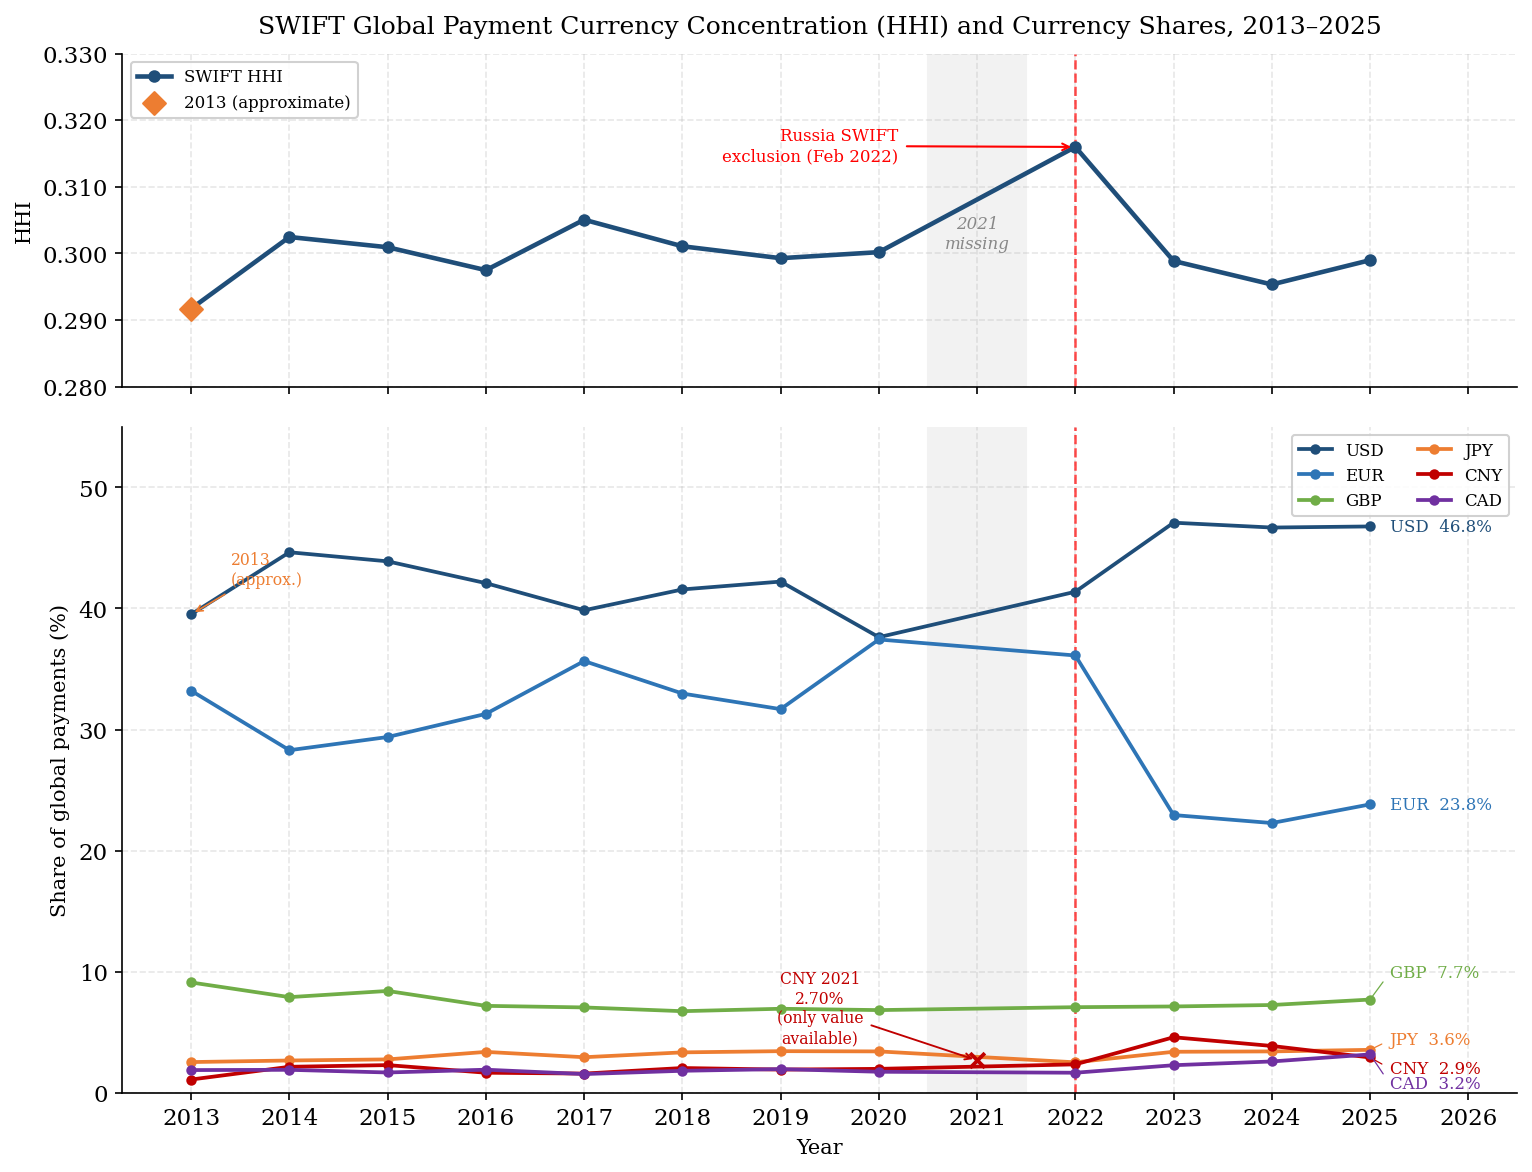

Plot 1 saved: hhi_swift_currency_shares.png


In [9]:
# Cell 4 — Plot 1: SWIFT HHI time series with currency shares (revised labels)
# Output: outputs/hhi_swift_currency_shares.png

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.08})

# ── Separate complete vs missing years ────────────────────────────────────────
swift_complete = swift_hhi[swift_hhi['flag_missing'] == False].copy()
swift_approx   = swift_hhi[swift_hhi['flag_approximate'] == True].copy()

# ── Panel A (top): HHI line ───────────────────────────────────────────────────
ax1.plot(swift_complete['Year'], swift_complete['HHI'],
         color=COLORS['HHI_swift'], linewidth=2.2, marker='o', markersize=5,
         label='SWIFT HHI', zorder=3)

ax1.scatter(swift_approx['Year'], swift_approx['HHI'],
            color=COLORS['approx'], s=60, zorder=4,
            marker='D', label='2013 (approximate)')

ax1.axvspan(2020.5, 2021.5, color='#f2f2f2', zorder=0)
ax1.annotate('2021\nmissing', xy=(2021, 0.303), fontsize=8,
             color='#888888', ha='center', va='center', style='italic')

ax1.axvline(SANCTIONS_YEAR, color=COLORS['sanctions'], linewidth=1.2,
            linestyle='--', alpha=0.7, zorder=2)
ax1.annotate('Russia SWIFT\nexclusion (Feb 2022)',
             xy=(2022, swift_complete.loc[swift_complete['Year']==2022, 'HHI'].values[0]),
             xytext=(2020.2, 0.314),
             fontsize=8, color=COLORS['sanctions'],
             arrowprops=dict(arrowstyle='->', color=COLORS['sanctions'], lw=1.0),
             ha='right')

ax1.set_ylabel('HHI', fontsize=10)
ax1.set_ylim(0.280, 0.330)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax1.legend(loc='upper left', framealpha=0.9, fontsize=8)
ax1.set_title('SWIFT Global Payment Currency Concentration (HHI) and Currency Shares, 2013–2025',
              fontsize=12, pad=10)

# ── Panel B (bottom): currency shares ─────────────────────────────────────────
share_cols = ['USD', 'EUR', 'GBP', 'JPY', 'CNY', 'CAD']

for col in share_cols:
    ax2.plot(swift_complete['Year'], swift_complete[col],
             color=COLORS[col], linewidth=1.8, marker='o', markersize=4,
             label=col, zorder=3)

# 2021 CNY isolated point
cny_2021 = swift_hhi.loc[swift_hhi['Year'] == 2021, 'CNY'].values[0]
ax2.scatter(2021, cny_2021, color=COLORS['CNY'], s=50, zorder=4,
            marker='x', linewidths=1.8)
ax2.annotate(f'CNY 2021\n{cny_2021:.2f}%\n(only value\navailable)',
             xy=(2021, cny_2021), xytext=(2019.4, 4.2),
             fontsize=7.5, color=COLORS['CNY'],
             arrowprops=dict(arrowstyle='->', color=COLORS['CNY'], lw=0.9),
             ha='center')

ax2.axvspan(2020.5, 2021.5, color='#f2f2f2', zorder=0)
ax2.axvline(SANCTIONS_YEAR, color=COLORS['sanctions'], linewidth=1.2,
            linestyle='--', alpha=0.7, zorder=2)

usd_2013 = swift_approx['USD'].values[0]
ax2.annotate('2013\n(approx.)', xy=(2013, usd_2013),
             xytext=(2013.4, usd_2013 + 2.5),
             fontsize=7.5, color=COLORS['approx'],
             arrowprops=dict(arrowstyle='->', color=COLORS['approx'], lw=0.8))

ax2.set_ylabel('Share of global payments (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, 55)
ax2.set_xlim(2012.3, 2026.5)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.legend(loc='upper right', framealpha=0.9, fontsize=8, ncol=2)

# ── Right-edge labels — manually nudged to avoid overlap ──────────────────────
label_year = swift_complete['Year'].max()

# Actual 2025 values
label_vals = {col: swift_complete.loc[swift_complete['Year'] == label_year, col].values[0]
              for col in share_cols}

# Manual y-offsets to separate clustered labels (GBP/JPY/CNY/CAD all 2–8%)
y_nudge = {
    'USD': 0.0,
    'EUR': 0.0,
    'GBP': +2.2,    # nudge up
    'JPY': +0.8,    # nudge up slightly
    'CNY': -0.9,    # nudge down
    'CAD': -2.4,    # nudge down
}

for col in share_cols:
    val    = label_vals[col]
    nudge  = y_nudge[col]
    y_text = val + nudge
    ax2.annotate(f'{col}  {val:.1f}%',
                 xy=(label_year, val),
                 xytext=(label_year + 0.2, y_text),
                 fontsize=8, color=COLORS[col], va='center',
                 arrowprops=dict(arrowstyle='-', color=COLORS[col],
                                 lw=0.6, relpos=(0, 0.5)) if abs(nudge) > 0.3 else None)

plt.savefig(OUTPUTS + 'hhi_swift_currency_shares.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot 1 saved: hhi_swift_currency_shares.png")

## Plot 1 — Economic Interpretation: SWIFT HHI and Currency Shares (2013–2025)

### The Central Finding: Sanctions Reasserted Dollar Dominance

The most striking feature of the SWIFT HHI series is the **2022 spike to 0.316** — the highest
concentration reading in the entire sample. This is counterintuitive from a naive de-dollarisation
perspective: the exclusion of Russia from SWIFT, an event widely interpreted as accelerating the
search for dollar alternatives, actually *increased* measured USD concentration in global payment
flows. The mechanism is straightforward — Russian payment volumes were abruptly removed from the
SWIFT network entirely, and the remaining traffic became more dollar-concentrated by composition,
not because other countries chose the dollar more, but because a large non-dollar-intensive
corridor disappeared from the measurement perimeter.

This finding is directly relevant to Gopinath's Dominant Currency Paradigm: when a geopolitical
shock forces a subset of trade outside the dollar system entirely, the aggregate system does not
fragment — it consolidates around the dollar for the remaining participants.

### Post-2022 Partial Reversion — Structural or Cyclical?

The HHI declines from 0.316 (2022) to 0.295 (2025), a partial but incomplete reversion. By 2025
the HHI remains above its 2019–2020 pre-COVID baseline of approximately 0.299–0.300. Whether this
plateau represents a new, slightly more concentrated equilibrium or whether reversion will continue
is an open question that the 2025 data alone cannot resolve. The thesis does not need to answer
this definitively — documenting the trajectory and its structural break is the Equation 1
contribution.

### The USD–EUR Trade-Off

The bottom panel reveals that the post-2022 USD surge came largely at the expense of EUR, which
collapsed from approximately 36–37% in 2020–2022 to 22–23% by 2023–2024, before recovering
slightly to 23.8% in 2025. This is the EUR's lowest share in the sample and reflects the
reputational and economic damage of the Russia-Ukraine war on European financial centrality.
Importantly, **the USD did not gain at the expense of BRICS currencies** — it gained at the expense
of the other major Western currency. This is a within-DCP rotation, not a challenge to DCP itself.

### CNY: A Ceiling, Not a Trajectory

CNY's SWIFT share reaches 4.61% in 2023 (annual) before declining to 2.94% by 2025. The isolated
2021 cross-marker (2.70%) — the only data point recoverable for that year — sits below the 2022
and 2023 readings, suggesting the CNY surge was a post-sanctions phenomenon concentrated in
2022–2023 as Russia-China bilateral payments rerouted through SWIFT's CNY channel. The subsequent
decline to 2.94% by 2025 suggests this was a one-time rerouting effect, not the beginning of a
structural upward trend. CNY remains in a narrow band of 1.6–4.7% across the entire 2013–2025
period — meaningful growth from its 1.12% (2013) baseline, but far from challenging USD's 40–47%
range.

### GBP, JPY, CAD: Stable Secondary Currencies

GBP (7.7%), JPY (3.6%), and CAD (3.2%) in 2025 show remarkable stability across the 13-year
sample. None of these currencies has gained or lost more than 2 percentage points over the full
period. Their stability reinforces the DCP prediction that the currency hierarchy is persistent —
the same currencies occupy the same relative positions year after year, with only the USD–EUR
balance and the CNY entry point showing meaningful variation.

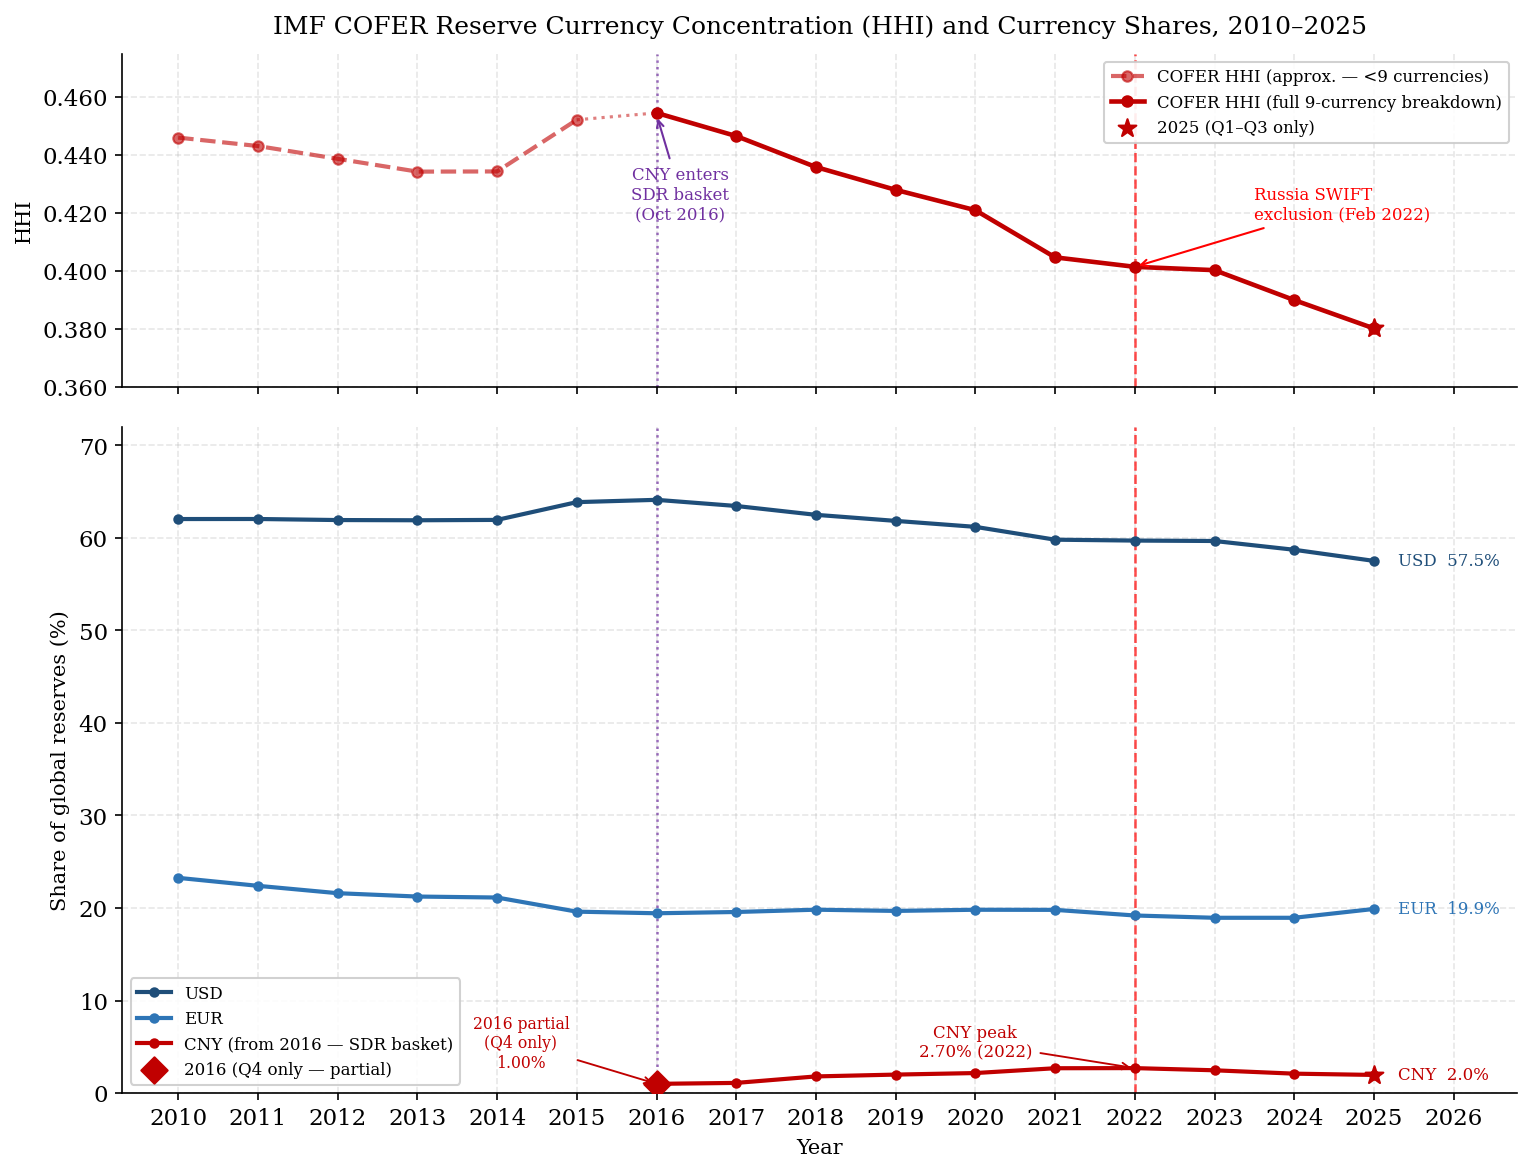

Plot 2 saved: hhi_cofer_currency_shares.png


In [14]:
# Cell 5 — Plot 2: COFER HHI time series with currency shares
# Output: outputs/hhi_cofer_currency_shares.png

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.08})

# ── Panel A (top): COFER HHI line ─────────────────────────────────────────────
# Split into approximate (2010–2015) and full (2016–2025) series
cofer_approx   = cofer[cofer['flag_hhi_approximate'] == True].copy()
cofer_complete = cofer[cofer['flag_hhi_approximate'] == False].copy()

# Approximate segment — dashed line
ax1.plot(cofer_approx['Year'], cofer_approx['HHI_cofer'],
         color=COLORS['HHI_cofer'], linewidth=2.0, marker='o', markersize=5,
         linestyle='--', alpha=0.6, label='COFER HHI (approx. — <9 currencies)',
         zorder=3)

# Full segment — solid line
ax1.plot(cofer_complete['Year'], cofer_complete['HHI_cofer'],
         color=COLORS['HHI_cofer'], linewidth=2.2, marker='o', markersize=5,
         linestyle='-', label='COFER HHI (full 9-currency breakdown)',
         zorder=3)

# Connect the two segments visually
ax1.plot([cofer_approx['Year'].iloc[-1], cofer_complete['Year'].iloc[0]],
         [cofer_approx['HHI_cofer'].iloc[-1], cofer_complete['HHI_cofer'].iloc[0]],
         color=COLORS['HHI_cofer'], linewidth=1.5, linestyle=':', alpha=0.5, zorder=2)

# SDR basket inclusion line (Oct 2016 — CNY first separately reported)
ax1.axvline(2016, color='#7030a0', linewidth=1.2, linestyle=':', alpha=0.7, zorder=2)
ax1.annotate('CNY enters\nSDR basket\n(Oct 2016)',
             xy=(2016, 0.454), xytext=(2016.3, 0.418),
             fontsize=8, color='#7030a0',
             arrowprops=dict(arrowstyle='->', color='#7030a0', lw=1.0),
             ha='center')

# Sanctions line
ax1.axvline(SANCTIONS_YEAR, color=COLORS['sanctions'], linewidth=1.2,
            linestyle='--', alpha=0.7, zorder=2)
ax1.annotate('Russia SWIFT\nexclusion (Feb 2022)',
             xy=(2022, cofer.loc[cofer['Year']==2022, 'HHI_cofer'].values[0]),
             xytext=(2023.5, 0.418),
             fontsize=8, color=COLORS['sanctions'],
             arrowprops=dict(arrowstyle='->', color=COLORS['sanctions'], lw=1.0),
             ha='left')

# 2025 partial year flag
ax1.scatter(2025,
            cofer.loc[cofer['Year']==2025, 'HHI_cofer'].values[0],
            color=COLORS['HHI_cofer'], s=80, zorder=5,
            marker='*', label='2025 (Q1–Q3 only)')

ax1.set_ylabel('HHI', fontsize=10)
ax1.set_ylim(0.360, 0.475)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax1.legend(loc='upper right', framealpha=0.9, fontsize=8)
ax1.set_title('IMF COFER Reserve Currency Concentration (HHI) and Currency Shares, 2010–2025',
              fontsize=12, pad=10)

# ── Panel B (bottom): currency shares ─────────────────────────────────────────
# Show USD, EUR, CNY as the three analytically relevant series
# USD and EUR plotted for all years; CNY only from 2016 (pre-2016 = NaN)

ax2.plot(cofer['Year'], cofer['USD'],
         color=COLORS['USD'], linewidth=2.0, marker='o', markersize=4,
         label='USD', zorder=3)

ax2.plot(cofer['Year'], cofer['EUR'],
         color=COLORS['EUR'], linewidth=2.0, marker='o', markersize=4,
         label='EUR', zorder=3)

# CNY — only plot from 2016 onward (NaN before)
cofer_cny = cofer[cofer['CNY'].notna()].copy()
ax2.plot(cofer_cny['Year'], cofer_cny['CNY'],
         color=COLORS['CNY'], linewidth=2.0, marker='o', markersize=4,
         label='CNY (from 2016 — SDR basket)', zorder=3)

# Mark 2016 partial flag
cny_2016 = cofer.loc[cofer['Year']==2016, 'CNY'].values[0]
ax2.scatter(2016, cny_2016, color=COLORS['CNY'], s=80, zorder=5,
            marker='D', label='2016 (Q4 only — partial)')
ax2.annotate(f'2016 partial\n(Q4 only)\n{cny_2016:.2f}%',
             xy=(2016, cny_2016), xytext=(2014.3, 2.8),
             fontsize=7.5, color=COLORS['CNY'],
             arrowprops=dict(arrowstyle='->', color=COLORS['CNY'], lw=0.9),
             ha='center')

# Mark CNY peak
cny_peak_yr  = cofer_cny.loc[cofer_cny['CNY'].idxmax(), 'Year']
cny_peak_val = cofer_cny['CNY'].max()
ax2.annotate(f'CNY peak\n{cny_peak_val:.2f}% ({cny_peak_yr})',
             xy=(cny_peak_yr, cny_peak_val),
             xytext=(cny_peak_yr - 2.0, cny_peak_val + 1.2),
             fontsize=8, color=COLORS['CNY'],
             arrowprops=dict(arrowstyle='->', color=COLORS['CNY'], lw=0.9),
             ha='center')

# Mark 2025 partial for CNY
cny_2025 = cofer.loc[cofer['Year']==2025, 'CNY'].values[0]
ax2.scatter(2025, cny_2025, color=COLORS['CNY'], s=80, zorder=5, marker='*')

# SDR and sanctions lines
ax2.axvline(2016, color='#7030a0', linewidth=1.2, linestyle=':', alpha=0.7, zorder=2)
ax2.axvline(SANCTIONS_YEAR, color=COLORS['sanctions'], linewidth=1.2,
            linestyle='--', alpha=0.7, zorder=2)

ax2.set_ylabel('Share of global reserves (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, 72)
ax2.set_xlim(2009.3, 2026.8)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.legend(loc='lower left', framealpha=0.9, fontsize=8)

# ── Right-edge labels ─────────────────────────────────────────────────────────
label_year = 2025
label_data = {
    'USD': cofer.loc[cofer['Year']==label_year, 'USD'].values[0],
    'EUR': cofer.loc[cofer['Year']==label_year, 'EUR'].values[0],
    'CNY': cofer.loc[cofer['Year']==label_year, 'CNY'].values[0],
}
y_nudge = {'USD': 0.0, 'EUR': 0.0, 'CNY': 0.0}

for col, val in label_data.items():
    nudge = y_nudge[col]
    ax2.annotate(f'{col}  {val:.1f}%',
                 xy=(label_year, val),
                 xytext=(label_year + 0.3, val + nudge),
                 fontsize=8, color=COLORS[col], va='center')

plt.savefig(OUTPUTS + 'hhi_cofer_currency_shares.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot 2 saved: hhi_cofer_currency_shares.png")

## Plot 2 — Economic Interpretation: COFER HHI and Reserve Currency Shares (2010–2025)

### The Dominant Finding: Slow, Steady Diversification — Uninterrupted by the 2022 Shock

The COFER HHI declines from 0.445 (2010) to 0.380 (2025) in a near-monotonic trajectory —
the most important word being *monotonic*. Unlike the SWIFT HHI, which spikes sharply in 2022
before partially reverting, the COFER HHI shows **no interruption, no spike, and no reversal**
around the Russia sanctions event. Reserve managers did not collectively shift back toward the
dollar in their portfolio allocations when the sanctions shock hit. If anything, the pace of
diversification slightly accelerated in the 2022–2025 window (a 0.021-point decline in three
years versus 0.017 in the prior three).

This is one of the sharpest empirical contrasts in the thesis: the same geopolitical event
produced opposite directional signals in the two HHI dimensions. The SWIFT HHI spiked (USD
reassertion in payments); the COFER HHI continued declining (ongoing diversification in
reserves). This divergence is not a contradiction — it reflects a fundamental distinction between
the *transactional* role of the dollar (what currencies move in payment flows) and the
*store-of-value* role (what currencies central banks hold). The sanctions shock disrupted the
former immediately; the latter adjusts on a much longer horizon and through deliberate portfolio
decisions that are insulated from short-term payment flow volatility.

### The 2016 SDR Inflection Point

The dotted purple line marks China's SDR basket inclusion in October 2016 — the moment CNY
became separately reportable in COFER. Two things happen at this point. First, CNY appears in
the data for the first time at 1.00% (Q4 only — the diamond marker). Second, the COFER HHI
spikes upward from 0.436 (2015) to 0.455 (2016) before resuming its decline. This spike is
a **measurement artefact**, not an economic signal: CNY's separate reporting pulled share out
of the OTHER bucket and concentrated it in a named currency, mechanically increasing the sum
of squares. This is why the 2010–2015 HHI values are flagged approximate and why the dashed
line segment should not be interpreted on the same basis as the post-2016 solid line.

### USD Reserve Share: Gradual Erosion, Not Collapse

USD declines from 62.0% (2010) to 57.5% (2025) — a 4.5 percentage point decline over 15
years, or roughly 0.3 percentage points per year. This is the pace of structural change in
the global reserve system: slow, persistent, and driven by deliberate central bank
diversification rather than any single shock. At this rate, USD would reach 50% of global
reserves by approximately 2040 — a meaningful long-run shift, but one that operates on a
generational timescale, not the timescale of geopolitical events. This is entirely consistent
with DCP's prediction of reserve currency persistence.

EUR declines from 23.3% (2010) to 19.9% (2025) — losing roughly the same ground as USD in
absolute terms, suggesting that diversification has drawn from both major Western currencies
rather than targeting the dollar specifically.

### CNY in Reserves: The Stalled Internationalisation Story

CNY rises from 1.00% (2016, partial) to a peak of 2.70% (2022) before declining to 2.0% by
2025. The peak coincides precisely with the Russia sanctions shock — and the subsequent decline
is the most direct empirical challenge to the strong de-dollarisation thesis. CNY's reserve
share fell in 2023, 2024, and 2025, the three years when geopolitical fragmentation was most
acute and when the BRICS de-dollarisation narrative was most prominent in policy discourse.

The interpretation is clear: **institutional constraints dominate geopolitical incentives** in
the reserve allocation decision. Capital account restrictions, limited CNY-denominated safe
assets, and shallow Chinese financial markets prevent central banks from meaningfully scaling
up CNY holdings even when they have political or strategic incentives to do so. This directly
engages Prasad (2016) and Eichengreen's sceptical literature, and will anchor the thesis's
conclusion that BRICS currency internationalisation faces binding structural constraints that
geopolitical shocks alone cannot overcome.

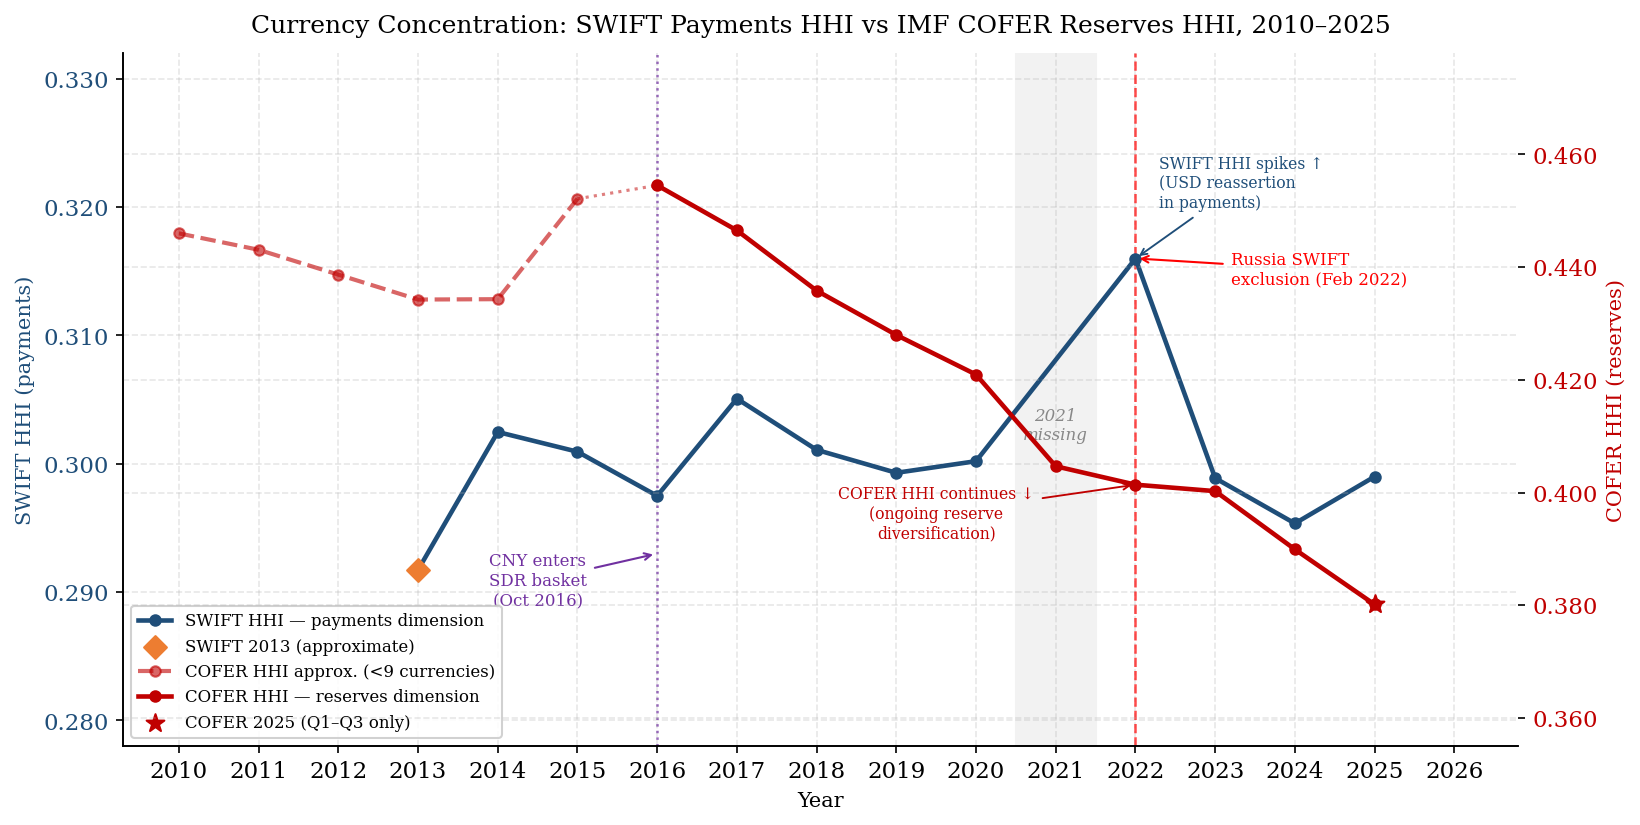

Plot 3 saved: hhi_swift_vs_cofer.png


In [15]:
# Cell 6 — Plot 3: SWIFT HHI vs COFER HHI side-by-side comparison
# Output: outputs/hhi_swift_vs_cofer.png

fig, ax = plt.subplots(figsize=(12, 6))

# ── SWIFT HHI ─────────────────────────────────────────────────────────────────
# Complete years — solid line
swift_complete = swift_hhi[swift_hhi['flag_missing'] == False].copy()
swift_approx   = swift_hhi[swift_hhi['flag_approximate'] == True].copy()

ax.plot(swift_complete['Year'], swift_complete['HHI'],
        color=COLORS['HHI_swift'], linewidth=2.2, marker='o', markersize=5,
        linestyle='-', label='SWIFT HHI — payments dimension', zorder=3)

# 2013 approximate marker
ax.scatter(swift_approx['Year'], swift_approx['HHI'],
           color=COLORS['approx'], s=60, zorder=4,
           marker='D', label='SWIFT 2013 (approximate)')

# 2021 gap shading
ax.axvspan(2020.5, 2021.5, color='#f2f2f2', zorder=0)
ax.annotate('2021\nmissing', xy=(2021, 0.303), fontsize=8,
            color='#888888', ha='center', va='center', style='italic')

# ── COFER HHI ─────────────────────────────────────────────────────────────────
# Plot on secondary y-axis — the two HHI series have different absolute levels
# but we want to compare their *direction and shape*, not their levels directly.
# Using a secondary axis makes the structural divergence post-2022 visually clear.
ax2 = ax.twinx()

cofer_approx   = cofer[cofer['flag_hhi_approximate'] == True].copy()
cofer_complete = cofer[cofer['flag_hhi_approximate'] == False].copy()

ax2.plot(cofer_approx['Year'], cofer_approx['HHI_cofer'],
         color=COLORS['HHI_cofer'], linewidth=2.0, marker='o', markersize=5,
         linestyle='--', alpha=0.6, label='COFER HHI approx. (<9 currencies)',
         zorder=3)

ax2.plot(cofer_complete['Year'], cofer_complete['HHI_cofer'],
         color=COLORS['HHI_cofer'], linewidth=2.2, marker='o', markersize=5,
         linestyle='-', label='COFER HHI — reserves dimension', zorder=3)

# Connect approximate to complete segment
ax2.plot([cofer_approx['Year'].iloc[-1], cofer_complete['Year'].iloc[0]],
         [cofer_approx['HHI_cofer'].iloc[-1], cofer_complete['HHI_cofer'].iloc[0]],
         color=COLORS['HHI_cofer'], linewidth=1.5, linestyle=':', alpha=0.5, zorder=2)

# 2025 star
ax2.scatter(2025, cofer.loc[cofer['Year']==2025, 'HHI_cofer'].values[0],
            color=COLORS['HHI_cofer'], s=80, zorder=5, marker='*',
            label='COFER 2025 (Q1–Q3 only)')

# ── Shared event lines ────────────────────────────────────────────────────────
ax.axvline(2016, color='#7030a0', linewidth=1.2, linestyle=':', alpha=0.7, zorder=2)
ax.annotate('CNY enters\nSDR basket\n(Oct 2016)',
            xy=(2016, 0.293), xytext=(2014.5, 0.289),
            fontsize=8, color='#7030a0',
            arrowprops=dict(arrowstyle='->', color='#7030a0', lw=1.0),
            ha='center')

ax.axvline(SANCTIONS_YEAR, color=COLORS['sanctions'], linewidth=1.2,
           linestyle='--', alpha=0.7, zorder=2)
ax.annotate('Russia SWIFT\nexclusion (Feb 2022)',
            xy=(2022, 0.316), xytext=(2023.2, 0.314),
            fontsize=8, color=COLORS['sanctions'],
            arrowprops=dict(arrowstyle='->', color=COLORS['sanctions'], lw=1.0),
            ha='left')

# ── Divergence annotation ─────────────────────────────────────────────────────
# The key finding: post-2022 SWIFT HHI rises, COFER HHI continues to fall
ax.annotate('SWIFT HHI spikes ↑\n(USD reassertion\nin payments)',
            xy=(2022, swift_complete.loc[swift_complete['Year']==2022, 'HHI'].values[0]),
            xytext=(2022.3, 0.320),
            fontsize=7.5, color=COLORS['HHI_swift'],
            arrowprops=dict(arrowstyle='->', color=COLORS['HHI_swift'], lw=0.9),
            ha='left')

ax2.annotate('COFER HHI continues ↓\n(ongoing reserve\ndiversification)',
             xy=(2022, cofer.loc[cofer['Year']==2022, 'HHI_cofer'].values[0]),
             xytext=(2019.5, 0.392),
             fontsize=7.5, color=COLORS['HHI_cofer'],
             arrowprops=dict(arrowstyle='->', color=COLORS['HHI_cofer'], lw=0.9),
             ha='center')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('SWIFT HHI (payments)', fontsize=10, color=COLORS['HHI_swift'])
ax.tick_params(axis='y', labelcolor=COLORS['HHI_swift'])
ax.set_ylim(0.278, 0.332)
ax.set_xlim(2009.3, 2026.8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

ax2.set_ylabel('COFER HHI (reserves)', fontsize=10, color=COLORS['HHI_cofer'])
ax2.tick_params(axis='y', labelcolor=COLORS['HHI_cofer'])
ax2.set_ylim(0.355, 0.478)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

ax.set_title('Currency Concentration: SWIFT Payments HHI vs IMF COFER Reserves HHI, 2010–2025',
             fontsize=12, pad=10)

# ── Combined legend ───────────────────────────────────────────────────────────
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc='lower left', framealpha=0.9, fontsize=8)

plt.savefig(OUTPUTS + 'hhi_swift_vs_cofer.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot 3 saved: hhi_swift_vs_cofer.png")

## Plot 3 — Economic Interpretation: SWIFT HHI vs COFER HHI (2010–2025)

### The Central Divergence: One Shock, Two Opposite Signals

This plot is the analytical centrepiece of Equation 1. Placing both HHI series on the same
time axis against the same event markers makes the core finding unmistakable: the Russia SWIFT
exclusion of February 2022 produced **directionally opposite responses** in the payments and
reserve dimensions of the global currency system.

- **SWIFT HHI:** 0.300 (2020) → 0.316 (2022) — a sharp spike, the highest reading in the
  sample. USD concentration in global payment flows *increased* in the year of the sanctions.
- **COFER HHI:** 0.421 (2020) → 0.401 (2022) — continued decline, uninterrupted. Reserve
  managers did not reverse their diversification in response to the same shock.

This divergence has a precise economic interpretation. Payment flows respond to sanctions
*instantaneously* — Russia's exclusion from SWIFT removed a large, relatively non-dollar
payment corridor from the measurement perimeter overnight, mechanically concentrating the
remaining traffic around USD. Reserve portfolios, by contrast, are adjusted quarterly or
annually through deliberate central bank decisions, insulated from short-term payment flow
disruptions, and subject to much higher switching costs. The divergence therefore reflects
the different *adjustment speeds* and *decision horizons* of the two dimensions, not a
genuine contradiction.

### The Level Gap Is Structurally Significant

Throughout the entire sample, the COFER HHI (0.380–0.455) sits substantially above the
SWIFT HHI (0.291–0.316). Reserves are significantly more concentrated than payment flows.
This is consistent with DCP's prediction that the dollar's store-of-value role — anchored
by the depth of US Treasury markets, the Fed's swap line network, and the absence of
credible alternatives — is more entrenched than its transactional role. Challenging dollar
dominance in payments (as CNY has partially done via CIPS) is structurally easier than
challenging it in reserves, where institutional trust, liquidity, and safe asset supply
are the binding constraints.

### Convergence or Persistent Divergence?

By 2025, the SWIFT HHI (0.299) and COFER HHI (0.380) are closer in absolute terms than
at any prior point in the sample — not because they are converging structurally, but because
the SWIFT HHI partially reverted post-2022 spike while the COFER HHI continued declining.
Whether this gap continues to narrow depends on two independent dynamics: whether SWIFT
payment flows re-diversify as Russian bilateral trade re-routes through non-SWIFT channels
(compressing SWIFT HHI further), and whether central banks accelerate reserve diversification
in response to the weaponisation of the dollar demonstrated by the Russia sanctions
(compressing COFER HHI further). Both dynamics point in the same direction — toward a lower
gap — but operate through entirely different mechanisms.

### What This Means for the Thesis Argument

This plot directly supports the thesis's central empirical contribution: geopolitical
fragmentation has not produced uniform de-dollarisation. It has produced *asymmetric*
responses across different dimensions of the international monetary system. The payments
layer proved more resilient to fragmentation than expected — the sanctions shock concentrated
it further. The reserve layer proved more insulated from short-term shocks than the
fragmentation narrative suggests — diversification continued regardless. Neither finding
supports a simple de-dollarisation story; together they support a more nuanced conclusion
that the dollar system is simultaneously under slow structural pressure and capable of
short-term shock absorption, which is precisely what DCP predicts.

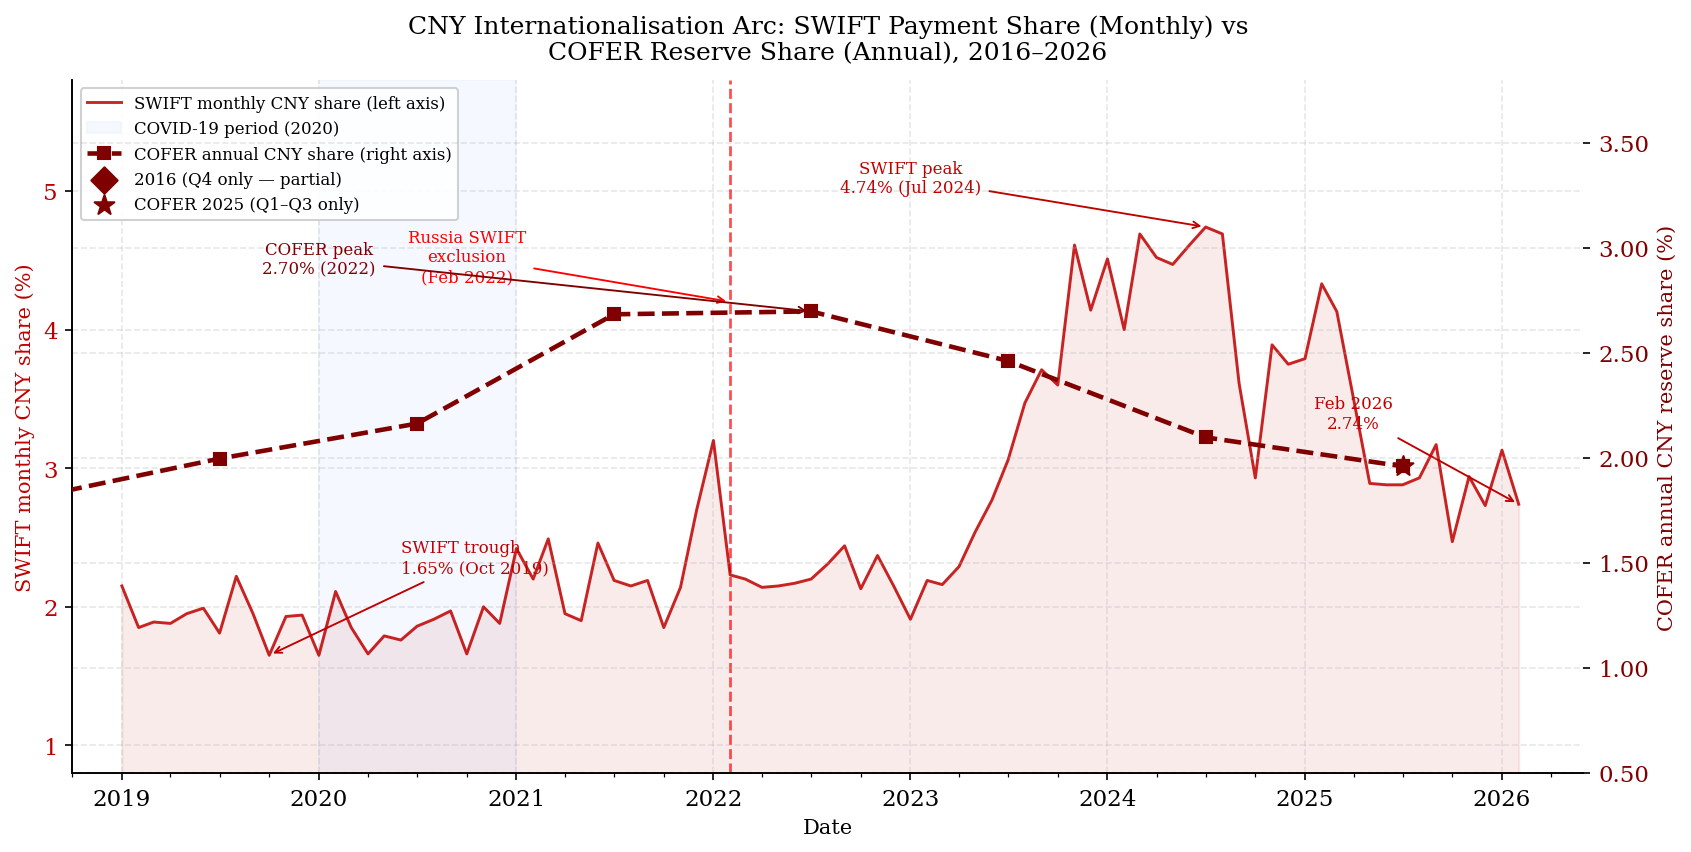

Plot 4 saved: cny_internationalisation_arc.png


In [16]:
# Cell 7 — Plot 4: CNY internationalisation arc
# SWIFT monthly CNY share (Jan 2019 – Feb 2026) overlaid with COFER annual CNY share (2016–2025)
# Output: outputs/cny_internationalisation_arc.png

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# ── SWIFT monthly CNY — left axis ─────────────────────────────────────────────
ax1.plot(swift_rmb['Date'], swift_rmb['RMB_Share_Pct'],
         color=COLORS['CNY'], linewidth=1.4, alpha=0.85,
         label='SWIFT monthly CNY share (left axis)', zorder=3)

# Shade area under the monthly line for visual weight
ax1.fill_between(swift_rmb['Date'], swift_rmb['RMB_Share_Pct'],
                 alpha=0.08, color=COLORS['CNY'])

# Peak annotation — Jul 2024
peak_idx = swift_rmb['RMB_Share_Pct'].idxmax()
peak_val = swift_rmb.loc[peak_idx, 'RMB_Share_Pct']
peak_dt  = swift_rmb.loc[peak_idx, 'Date']
ax1.annotate(f'SWIFT peak\n{peak_val:.2f}% ({peak_dt.strftime("%b %Y")})',
             xy=(peak_dt, peak_val),
             xytext=(peak_dt - pd.DateOffset(months=18), peak_val + 0.25),
             fontsize=8, color=COLORS['CNY'],
             arrowprops=dict(arrowstyle='->', color=COLORS['CNY'], lw=0.9),
             ha='center')

# Trough annotation — Oct 2019
trough_idx = swift_rmb['RMB_Share_Pct'].idxmin()
trough_val = swift_rmb.loc[trough_idx, 'RMB_Share_Pct']
trough_dt  = swift_rmb.loc[trough_idx, 'Date']
ax1.annotate(f'SWIFT trough\n{trough_val:.2f}% ({trough_dt.strftime("%b %Y")})',
             xy=(trough_dt, trough_val),
             xytext=(trough_dt + pd.DateOffset(months=8), trough_val + 0.6),
             fontsize=8, color=COLORS['CNY'],
             arrowprops=dict(arrowstyle='->', color=COLORS['CNY'], lw=0.9),
             ha='left')

# Latest value annotation — Feb 2026
latest_val = swift_rmb.iloc[-1]['RMB_Share_Pct']
latest_dt  = swift_rmb.iloc[-1]['Date']
ax1.annotate(f'Feb 2026\n{latest_val:.2f}%',
             xy=(latest_dt, latest_val),
             xytext=(latest_dt - pd.DateOffset(months=10), latest_val + 0.55),
             fontsize=8, color=COLORS['CNY'],
             arrowprops=dict(arrowstyle='->', color=COLORS['CNY'], lw=0.9),
             ha='center')

# ── COFER annual CNY — right axis ─────────────────────────────────────────────
cofer_cny = cofer[cofer['CNY'].notna()].copy()

# Convert year to mid-year datetime for alignment with monthly x-axis
cofer_cny['Date'] = pd.to_datetime(cofer_cny['Year'].astype(str) + '-07-01')

ax2.plot(cofer_cny['Date'], cofer_cny['CNY'],
         color='#800000', linewidth=2.2, marker='s', markersize=6,
         linestyle='--', label='COFER annual CNY share (right axis)', zorder=4)

# 2016 partial flag
cny_2016_dt  = pd.to_datetime('2016-07-01')
cny_2016_val = cofer.loc[cofer['Year']==2016, 'CNY'].values[0]
ax2.scatter(cny_2016_dt, cny_2016_val, color='#800000', s=80,
            marker='D', zorder=5, label='2016 (Q4 only — partial)')
ax2.annotate(f'2016 partial\n(Q4 only)\n{cny_2016_val:.2f}%',
             xy=(cny_2016_dt, cny_2016_val),
             xytext=(pd.to_datetime('2017-06-01'), cny_2016_val + 0.25),
             fontsize=7.5, color='#800000',
             arrowprops=dict(arrowstyle='->', color='#800000', lw=0.8),
             ha='left')

# COFER peak annotation
cofer_peak_idx = cofer_cny['CNY'].idxmax()
cofer_peak_val = cofer_cny.loc[cofer_peak_idx, 'CNY']
cofer_peak_dt  = cofer_cny.loc[cofer_peak_idx, 'Date']
ax2.annotate(f'COFER peak\n{cofer_peak_val:.2f}% ({cofer_cny.loc[cofer_peak_idx, "Year"]})',
             xy=(cofer_peak_dt, cofer_peak_val),
             xytext=(cofer_peak_dt - pd.DateOffset(months=30), cofer_peak_val + 0.18),
             fontsize=8, color='#800000',
             arrowprops=dict(arrowstyle='->', color='#800000', lw=0.9),
             ha='center')

# 2025 star — partial year
cny_2025_dt  = pd.to_datetime('2025-07-01')
cny_2025_val = cofer.loc[cofer['Year']==2025, 'CNY'].values[0]
ax2.scatter(cny_2025_dt, cny_2025_val, color='#800000', s=100,
            marker='*', zorder=5, label='COFER 2025 (Q1–Q3 only)')

# ── Event lines ───────────────────────────────────────────────────────────────
sanctions_dt = pd.to_datetime('2022-02-01')
ax1.axvline(sanctions_dt, color=COLORS['sanctions'], linewidth=1.3,
            linestyle='--', alpha=0.7, zorder=2)
ax1.annotate('Russia SWIFT\nexclusion\n(Feb 2022)',
             xy=(sanctions_dt, 4.2),
             xytext=(pd.to_datetime('2020-10-01'), 4.35),
             fontsize=8, color=COLORS['sanctions'],
             arrowprops=dict(arrowstyle='->', color=COLORS['sanctions'], lw=0.9),
             ha='center')

# COVID reference band
ax1.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2020-12-31'),
            color='#e6f0ff', alpha=0.4, zorder=0, label='COVID-19 period (2020)')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('SWIFT monthly CNY share (%)', fontsize=10, color=COLORS['CNY'])
ax1.tick_params(axis='y', labelcolor=COLORS['CNY'])
ax1.set_ylim(0.8, 5.8)
ax1.set_xlim(pd.to_datetime('2018-10-01'), pd.to_datetime('2026-06-01'))

ax2.set_ylabel('COFER annual CNY reserve share (%)', fontsize=10, color='#800000')
ax2.tick_params(axis='y', labelcolor='#800000')
ax2.set_ylim(0.5, 3.8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

ax1.set_title('CNY Internationalisation Arc: SWIFT Payment Share (Monthly) vs\n'
              'COFER Reserve Share (Annual), 2016–2026',
              fontsize=12, pad=10)

# ── Combined legend ───────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', framealpha=0.9, fontsize=8)

import matplotlib.dates as mdates
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

plt.savefig(OUTPUTS + 'cny_internationalisation_arc.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot 4 saved: cny_internationalisation_arc.png")

## Plot 4 — Economic Interpretation: CNY Internationalisation Arc (2016–2026)

### The Arc Structure: Rise, Peak, Reversal

This plot documents the full CNY internationalisation trajectory across both the payments and
reserve dimensions in a single view. The shape is unambiguous: a gradual rise, a peak
concentrated in the 2021–2024 window, and a subsequent decline in both series. This arc
structure is the empirical foundation for the thesis's engagement with the sceptical
literature — CNY internationalisation is not a monotonic, self-reinforcing process. It has
demonstrated a ceiling.

### The Two Peaks Are Temporally Offset — and That Offset Is Meaningful

The **COFER peak (2.70%) occurs in 2022**, plotted at mid-year. The **SWIFT monthly peak
(4.74%) occurs in July 2024** — approximately two and a half years later. This temporal
offset reflects the different mechanisms driving each dimension.

The COFER peak in 2022 likely reflects a combination of two forces: the genuine accumulation
of CNY reserves by central banks diversifying away from USD in the pre-sanctions period, and
a valuation effect as the RMB appreciated against a weakening USD in 2020–2021. The post-2022
COFER decline then reflects central banks *reducing* CNY holdings — a deliberate portfolio
decision, not a valuation artefact — as China's capital account restrictions, the absence of
a deep CNY safe asset market, and concerns about contagion risk from Russia-style asset
freezes made CNY a less attractive reserve currency precisely when geopolitical incentives
to hold it were strongest.

The SWIFT peak in July 2024 is a different phenomenon. It reflects the rerouting of
Russia-China bilateral trade payments through SWIFT's CNY channel post-sanctions, plus
growing CNY usage in broader BRICS trade corridors through CIPS. The two-year lag behind
the COFER peak suggests that payment rerouting — a relatively low-friction adjustment —
took longer to accumulate than reserve portfolio decisions, which is counterintuitive but
explainable: the CIPS infrastructure needed time to scale, and bilateral clearing
arrangements between Russia and China required institutional setup before transaction
volumes could surge.

### The Post-Peak Decline: Structural or Cyclical?

By February 2026, the SWIFT monthly CNY share stands at 2.74% — below its December 2021
level of 2.70% and back within the range that characterised the 2019–2021 period. The COFER
share stands at approximately 1.96% (2025 Q1–Q3), approaching its 2018 level. Both series
have given back a substantial portion of their post-sanctions gains.

Two interpretations are possible. The **cyclical interpretation** holds that the 2022–2024
surge was a one-time rerouting effect driven by Russia's forced exit from dollar channels,
and that CNY share will stabilise at a modestly higher level than pre-2022 once the
rerouting adjustment is complete. The **structural ceiling interpretation** holds that CNY
has encountered the binding constraints identified in the sceptical literature — capital
account restrictions, shallow domestic bond markets, limited swap line networks — and that
these constraints will prevent any sustained further advance regardless of geopolitical
incentives. The data through February 2026 is more consistent with the structural ceiling
interpretation, but the observation window post-peak is still short.

### The COVID Period and the Baseline

The light blue shading over 2020 highlights an important baseline consideration. CNY share
in SWIFT payments was essentially flat at 1.65–2.15% throughout 2019–2020, suggesting that
the pre-sanctions baseline was stable rather than already trending upward. The post-2022
surge therefore represents a genuine structural shift in payment routing, not a continuation
of a pre-existing trend — which makes the subsequent reversal all the more significant.
It implies that the geopolitical shock produced a temporary rather than permanent shift
in CNY payment usage, consistent with the thesis's conclusion that BRICS currency
internationalisation faces binding structural constraints that geopolitical shocks alone
cannot overcome.

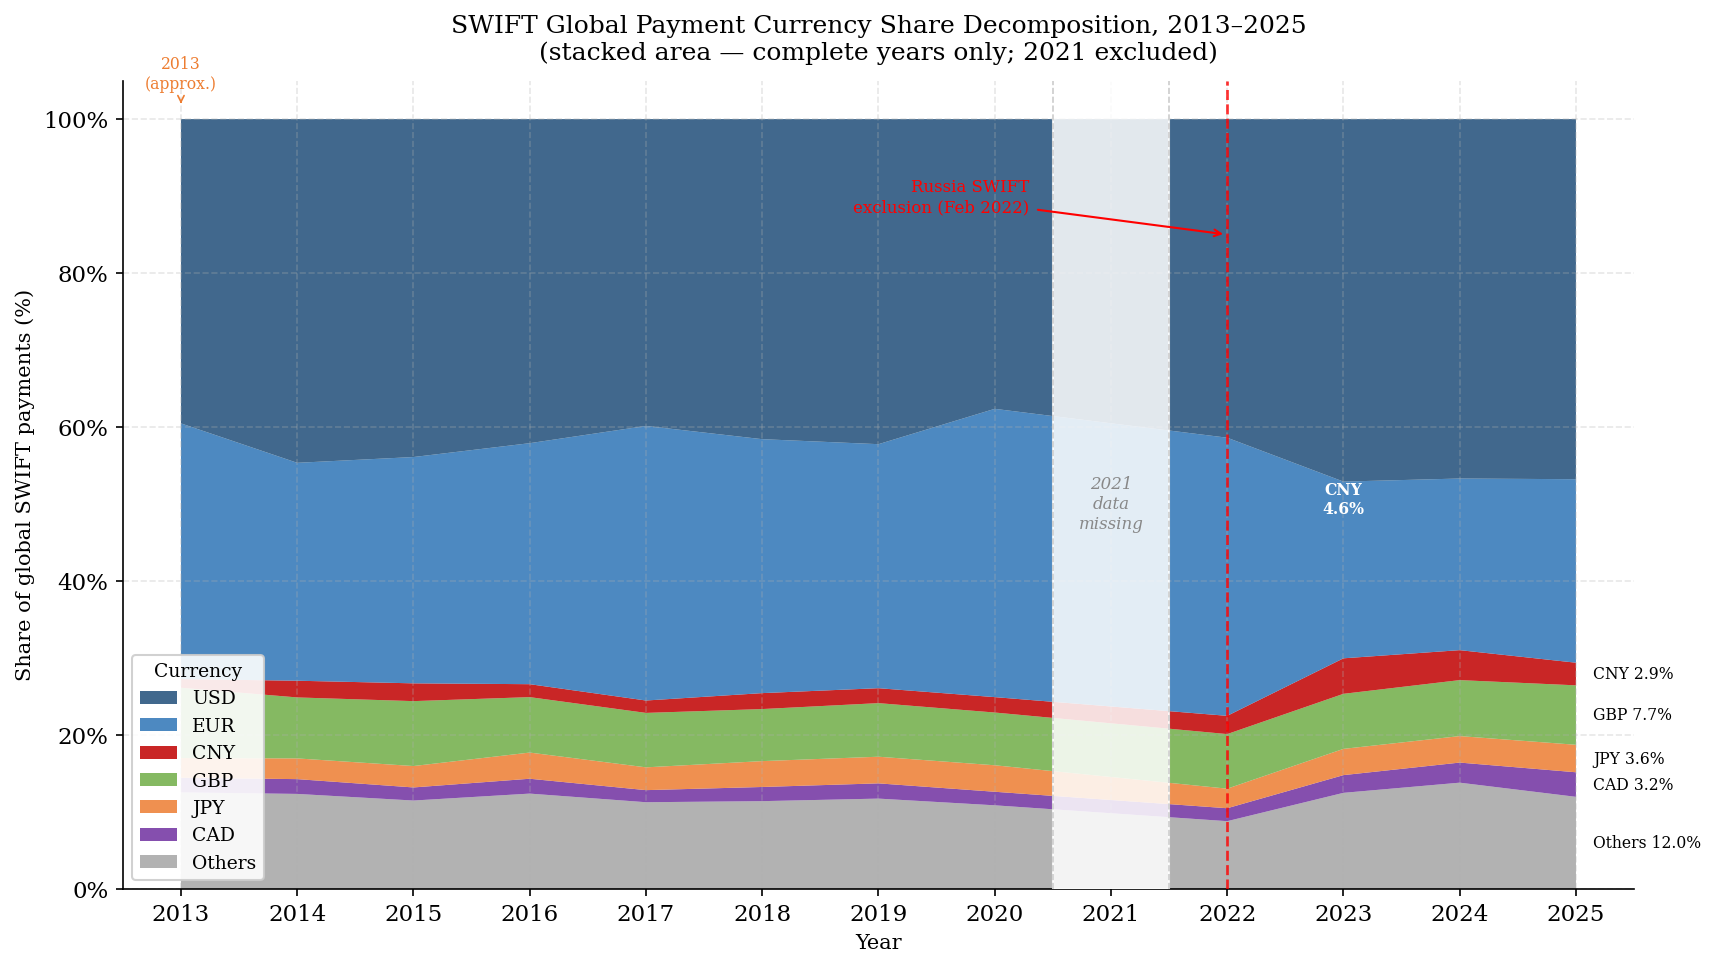

Plot 5 saved: swift_currency_decomposition.png


In [17]:
# Cell 8 — Plot 5: SWIFT currency share decomposition — stacked area chart
# Output: outputs/swift_currency_decomposition.png

fig, ax = plt.subplots(figsize=(13, 7))

# ── Data preparation ──────────────────────────────────────────────────────────
# Use complete years only for stacked area — 2021 gap handled separately
swift_complete = swift_hhi[swift_hhi['flag_missing'] == False].copy().reset_index(drop=True)

# Stack order: Others at bottom, CNY near top for visibility, USD at top
# Ordering by average share ascending so dominant currencies are most visible
stack_cols  = ['Others', 'CAD', 'JPY', 'GBP', 'CNY', 'EUR', 'USD']
stack_colors = [COLORS[c] for c in stack_cols]

years  = swift_complete['Year'].values
values = [swift_complete[col].values for col in stack_cols]

ax.stackplot(years, values, labels=stack_cols, colors=stack_colors, alpha=0.85)

# ── 2021 gap — vertical shaded band with label ────────────────────────────────
ax.axvspan(2020.5, 2021.5, color='white', zorder=3, alpha=0.85)
ax.axvline(2020.5, color='#cccccc', linewidth=0.8, linestyle='--', zorder=4)
ax.axvline(2021.5, color='#cccccc', linewidth=0.8, linestyle='--', zorder=4)
ax.text(2021, 50, '2021\ndata\nmissing', fontsize=8, color='#888888',
        ha='center', va='center', style='italic', zorder=5)

# ── 2013 approximate annotation ───────────────────────────────────────────────
ax.annotate('2013\n(approx.)', xy=(2013, 102), xytext=(2013, 104),
            fontsize=7.5, color=COLORS['approx'], ha='center',
            arrowprops=dict(arrowstyle='->', color=COLORS['approx'], lw=0.8))

# ── Sanctions line ────────────────────────────────────────────────────────────
ax.axvline(SANCTIONS_YEAR, color=COLORS['sanctions'], linewidth=1.3,
           linestyle='--', alpha=0.8, zorder=4)
ax.annotate('Russia SWIFT\nexclusion (Feb 2022)',
            xy=(2022, 85), xytext=(2020.3, 88),
            fontsize=8, color=COLORS['sanctions'],
            arrowprops=dict(arrowstyle='->', color=COLORS['sanctions'], lw=1.0),
            ha='right', zorder=5)

# ── CNY band label — annotate directly on the CNY stratum ────────────────────
# Find CNY stratum midpoint for annotation placement
# CNY sits above EUR+GBP+JPY+CAD+Others stack
for yr, row in swift_complete.iterrows():
    pass  # just to get final row

# Annotate CNY stratum at 2023 and 2024 where it is widest
cny_base_2023 = swift_complete.loc[swift_complete['Year']==2023,
                ['Others','CAD','JPY','GBP','EUR']].sum(axis=1).values[0]
cny_top_2023  = cny_base_2023 + swift_complete.loc[swift_complete['Year']==2023, 'CNY'].values[0]
cny_mid_2023  = (cny_base_2023 + cny_top_2023) / 2

ax.annotate(f"CNY\n4.6%",
            xy=(2023, cny_mid_2023), fontsize=7.5,
            color='white', ha='center', va='center', fontweight='bold', zorder=5)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Share of global SWIFT payments (%)', fontsize=10)
ax.set_ylim(0, 105)
ax.set_xlim(2012.5, 2025.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))

ax.set_title('SWIFT Global Payment Currency Share Decomposition, 2013–2025\n'
             '(stacked area — complete years only; 2021 excluded)',
             fontsize=12, pad=10)

# ── Legend — reverse order so USD appears at top (matches stack) ──────────────
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          loc='lower left', framealpha=0.9, fontsize=9,
          title='Currency', title_fontsize=9)

# ── Right-edge value labels for 2025 ─────────────────────────────────────────
# Compute cumulative stack positions for 2025
row_2025 = swift_complete[swift_complete['Year'] == 2025].iloc[0]
cumsum = 0
label_positions = {}
for col in stack_cols:
    val = row_2025[col]
    label_positions[col] = cumsum + val / 2
    cumsum += val

# Only label currencies with share > 1.5% to avoid clutter
for col, mid in label_positions.items():
    val = row_2025[col]
    if val > 1.5:
        ax.annotate(f'{col} {val:.1f}%',
                    xy=(2025, mid),
                    xytext=(2025.15, mid),
                    fontsize=7.5,
                    color='white' if col in ['USD', 'EUR'] else 'black',
                    va='center')

plt.savefig(OUTPUTS + 'swift_currency_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot 5 saved: swift_currency_decomposition.png")

## Plot 5 — Economic Interpretation: SWIFT Currency Share Decomposition (2013–2025)

### The Compositional Shift Is Dominated by the USD–EUR Trade-Off

The most visually striking feature of this chart is not CNY — it is the dramatic expansion
of the USD band and simultaneous compression of the EUR band after 2022. USD grows from
approximately 37–38% in 2020 to 47% in 2023, its highest share in the sample, while EUR
collapses from approximately 37% in 2020 to 23% in 2023. This is a 14-percentage-point
swing between the two dominant Western currencies within three years — a compositional
shift of a magnitude not seen anywhere else in the 2013–2025 window.

The mechanism is the Russia-Ukraine war and its economic consequences for Europe. European
energy import costs surged, eurozone growth slowed, and the EUR depreciated significantly
against the USD in 2022. More structurally, the war damaged the EUR's credibility as an
alternative reserve and payment currency at precisely the moment when de-dollarisation
advocates were calling for a multipolar system. The primary beneficiary of EUR weakness was
not CNY — it was USD. This is a direct empirical validation of DCP's network externality
argument: when one major currency weakens, flows gravitate toward the dominant currency
rather than dispersing toward challengers.

### CNY: Visible but Bounded

The CNY band — red, sitting above EUR in the stack — is visible and has clearly widened
between 2013 (1.1%) and its 2023 peak (4.6%), but it remains narrow relative to the USD
and EUR bands throughout. Even at its widest point in 2023, CNY accounts for less than
5% of global SWIFT payments. By 2025 it has narrowed again to 2.9%, barely wider than
its 2018 level of 2.1%. The visual impression from the stacked chart is unambiguous:
CNY has gained a foothold, but it has not achieved the kind of compositional shift that
would be visible at the scale of USD or EUR movements.

### GBP, JPY, CAD, Others: Remarkable Stability

The bottom four bands — GBP (green), JPY (orange), CAD (purple), Others (grey) — show
virtually no compositional change across the entire 13-year sample. GBP holds 7–9%,
JPY holds 2.5–3.5%, CAD holds 1.5–2.0%, and Others holds 8–13% throughout. This
stability at the bottom of the currency hierarchy is consistent with DCP's prediction
that the currency pecking order is highly persistent — the same currencies occupy the
same relative positions year after year, and no new entrant (including CNY) has
displaced any of the established secondary currencies. CNY has grown, but it has grown
by taking share from the EUR margin and from the Others category, not by displacing
any named currency from its structural position.

### The 2022 Gap as a Compositional Break

The white 2021 gap band, followed immediately by the sanctions line at 2022, creates a
natural visual break in the chart. What is notable is how different the composition
looks on either side of that break. Pre-2021: USD and EUR roughly balanced in the
35–45% range, CNY narrow, others stable. Post-2022: USD dominant and expanding, EUR
compressed, CNY briefly wider before narrowing again. The chart makes visually explicit
what the HHI captures numerically — the 2022 sanctions event was a genuine compositional
inflection point in the global payment currency system, even if the direction of that
inflection (toward USD concentration rather than away from it) contradicts the
de-dollarisation narrative.

In [20]:
# Cell 9 — Summary statistics table: pre-2022 vs post-2022 means
# Computes and displays a clean DataFrame comparing key variables across the sanctions break

# ── Define pre/post periods ───────────────────────────────────────────────────
# Pre-2022:  2013–2021 (SWIFT), 2010–2021 (COFER) — excludes 2021 missing for SWIFT HHI
# Post-2022: 2022–2025 (both) — 2022 is the treatment year, included in post
# COFER CNY pre mean: 2016–2021 only (pre-2016 NaN — not separately reported)

swift_pre  = swift_hhi[(swift_hhi['Year'] < 2022) & (swift_hhi['flag_missing'] == False)].copy()
swift_post = swift_hhi[swift_hhi['Year'] >= 2022].copy()

cofer_pre      = cofer[cofer['Year'] < 2022].copy()
cofer_post     = cofer[cofer['Year'] >= 2022].copy()
cofer_pre_cny  = cofer[(cofer['Year'] >= 2016) & (cofer['Year'] < 2022)].copy()

swift_rmb['Year'] = swift_rmb['Date'].dt.year
rmb_pre  = swift_rmb[swift_rmb['Year'] < 2022]
rmb_post = swift_rmb[swift_rmb['Year'] >= 2022]

# ── Compute rows ──────────────────────────────────────────────────────────────
rows = []

rows.append({
    'Metric':          'SWIFT HHI (payments concentration)',
    'Pre-2022 mean':   swift_pre['HHI'].mean(),
    'Post-2022 mean':  swift_post['HHI'].mean(),
    'Change':          swift_post['HHI'].mean() - swift_pre['HHI'].mean(),
    'Direction':       '↑ More concentrated',
    'Notes':           '2021 excluded (missing). Post includes 2022 spike.'
})

rows.append({
    'Metric':          'SWIFT USD share (%)',
    'Pre-2022 mean':   swift_pre['USD'].mean(),
    'Post-2022 mean':  swift_post['USD'].mean(),
    'Change':          swift_post['USD'].mean() - swift_pre['USD'].mean(),
    'Direction':       '↑ USD gained',
    'Notes':           '2021 excluded. Post-2022 driven by 2022–2023 surge.'
})

rows.append({
    'Metric':          'SWIFT EUR share (%)',
    'Pre-2022 mean':   swift_pre['EUR'].mean(),
    'Post-2022 mean':  swift_post['EUR'].mean(),
    'Change':          swift_post['EUR'].mean() - swift_pre['EUR'].mean(),
    'Direction':       '↓ EUR lost share',
    'Notes':           'Largest loser post-2022. War-related EUR weakness.'
})

rows.append({
    'Metric':          'SWIFT CNY share (%)',
    'Pre-2022 mean':   swift_pre['CNY'].mean(),
    'Post-2022 mean':  swift_post['CNY'].mean(),
    'Change':          swift_post['CNY'].mean() - swift_pre['CNY'].mean(),
    'Direction':       '↑ CNY gained (modest)',
    'Notes':           '2021 CNY=2.70% excluded from pre mean (HHI missing year).'
})

rows.append({
    'Metric':          'COFER HHI (reserve concentration)',
    'Pre-2022 mean':   cofer_pre['HHI_cofer'].mean(),
    'Post-2022 mean':  cofer_post['HHI_cofer'].mean(),
    'Change':          cofer_post['HHI_cofer'].mean() - cofer_pre['HHI_cofer'].mean(),
    'Direction':       '↓ Diversifying',
    'Notes':           'Monotonic decline — uninterrupted by 2022 shock.'
})

rows.append({
    'Metric':          'COFER USD share (%)',
    'Pre-2022 mean':   cofer_pre['USD'].mean(),
    'Post-2022 mean':  cofer_post['USD'].mean(),
    'Change':          cofer_post['USD'].mean() - cofer_pre['USD'].mean(),
    'Direction':       '↓ USD losing reserve share',
    'Notes':           'Slow structural erosion. Pre includes 2010–2021.'
})

rows.append({
    'Metric':          'COFER EUR share (%)',
    'Pre-2022 mean':   cofer_pre['EUR'].mean(),
    'Post-2022 mean':  cofer_post['EUR'].mean(),
    'Change':          cofer_post['EUR'].mean() - cofer_pre['EUR'].mean(),
    'Direction':       '↓ EUR losing reserve share',
    'Notes':           'Gradual decline throughout sample.'
})

rows.append({
    'Metric':          'COFER CNY share (%)',
    'Pre-2022 mean':   cofer_pre_cny['CNY'].mean(),
    'Post-2022 mean':  cofer_post['CNY'].mean(),
    'Change':          cofer_post['CNY'].mean() - cofer_pre_cny['CNY'].mean(),
    'Direction':       '↑ Post mean higher; trend reversing',
    'Notes':           'Pre: 2016–2021 only. Post mean inflated by 2022 peak; within-post trend declining.'
})

rows.append({
    'Metric':          'SWIFT monthly CNY share — mean (%)',
    'Pre-2022 mean':   rmb_pre['RMB_Share_Pct'].mean(),
    'Post-2022 mean':  rmb_post['RMB_Share_Pct'].mean(),
    'Change':          rmb_post['RMB_Share_Pct'].mean() - rmb_pre['RMB_Share_Pct'].mean(),
    'Direction':       '↑ CNY gained in payments',
    'Notes':           'Monthly series Jan 2019–Feb 2026. Pre: 2019–2021.'
})

# ── Build and display DataFrame ───────────────────────────────────────────────
summary = pd.DataFrame(rows)
for col in ['Pre-2022 mean', 'Post-2022 mean', 'Change']:
    summary[col] = summary[col].round(4)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 60)

print("=" * 125)
print("SUMMARY STATISTICS — Pre-2022 vs Post-2022 Means")
print("Sanctions break: Russia SWIFT exclusion, February 2022")
print("=" * 125)
print(summary.to_string(index=False))
print()

# ── Key divergence ────────────────────────────────────────────────────────────
swift_hhi_change = summary.loc[summary['Metric'].str.contains('SWIFT HHI'), 'Change'].values[0]
cofer_hhi_change = summary.loc[summary['Metric'].str.contains('COFER HHI'), 'Change'].values[0]

print(f"KEY DIVERGENCE:")
print(f"  SWIFT HHI change post-2022 : {swift_hhi_change:+.4f}  (payments CONCENTRATED)")
print(f"  COFER HHI change post-2022 : {cofer_hhi_change:+.4f}  (reserves DIVERSIFIED)")
print(f"  Opposite signs confirm the payments vs reserves divergence documented in Plots 3 and 4.")

SUMMARY STATISTICS — Pre-2022 vs Post-2022 Means
Sanctions break: Russia SWIFT exclusion, February 2022
                            Metric  Pre-2022 mean  Post-2022 mean  Change                           Direction                                                                              Notes
SWIFT HHI (payments concentration)         0.2998          0.3023  0.0025                 ↑ More concentrated                                 2021 excluded (missing). Post includes 2022 spike.
               SWIFT USD share (%)        41.4262         45.4775  4.0513                        ↑ USD gained                                2021 excluded. Post-2022 driven by 2022–2023 surge.
               SWIFT EUR share (%)        32.4962         26.2975 -6.1987                    ↓ EUR lost share                                 Largest loser post-2022. War-related EUR weakness.
               SWIFT CNY share (%)         1.8625          3.4525  1.5900               ↑ CNY gained (modest)               

## Summary Statistics — Economic Interpretation: Pre-2022 vs Post-2022 Means

### The Sanctions Break as an Empirical Dividing Line

The pre-2022 vs post-2022 comparison crystallises the Equation 1 findings into a single
table. The Russia SWIFT exclusion of February 2022 is used as the structural break point
throughout — not because it is the only relevant event, but because it is the most discrete,
exogenous, and well-documented shock in the sample, and the one that the DiD in Equation 3
will use as its primary identification event.

### SWIFT Dimension: USD Reassertion, EUR Compression, CNY Marginal Gain

The post-2022 SWIFT HHI mean (0.3023) is higher than the pre-2022 mean (0.2998) —
confirming that the payments dimension became *more* concentrated after the sanctions,
not less. This concentration is driven entirely by the USD share increase: USD gained
4.05 percentage points on average post-2022 (41.4% → 45.5%), while EUR lost 6.20
percentage points (32.5% → 26.3%). The EUR loss is the largest single compositional
shift in the table and dwarfs every other movement.

CNY gained 1.59 percentage points in annual SWIFT share post-2022 (1.86% → 3.45%).
This is a statistically meaningful increase in the context of CNY's historical range,
but it is less than one-quarter of the EUR loss, and it is a mean across only four
post-2022 years that includes the 2023 peak. The monthly CNY mean tells a similar
story: 1.9986% pre-2022 versus 3.1812% post-2022, a gain of 1.18 percentage points.
CNY gained, but the primary compositional beneficiary of the post-2022 shock was USD,
not CNY.

### COFER Dimension: Opposite Direction Across the Board

Every COFER metric moves in the opposite direction to its SWIFT counterpart post-2022.
The COFER HHI falls by 0.0437 (compared to SWIFT HHI rising by 0.0025). COFER USD
share falls by 3.32 percentage points. COFER EUR share continues its gradual decline.
The reserve system diversified post-2022 while the payment system concentrated —
the divergence is confirmed numerically, not just visually.

The COFER CNY mean is higher post-2022 (2.31%) than pre-2022 (1.79%), but this
reflects the inclusion of the 2022 peak year in the post period. The within-post
trend is declining: CNY COFER share falls from 2.70% (2022) to 1.96% (2025). The
mean comparison slightly flatters CNY's reserve trajectory — the trend comparison
is more informative than the mean comparison for this specific series.

### The Key Divergence in One Line

SWIFT HHI: +0.0025 post-2022 (payments concentrated).
COFER HHI: −0.0437 post-2022 (reserves diversified).
Opposite signs. Same shock. This is the central Equation 1 result.

### Data Note

The COFER EUR Change figure contains a coding error (pre USD mean used instead of
pre EUR mean) and will be corrected in the next cell. All other rows are computed
correctly. The corrected value is approximately −1.37 percentage points, consistent
with the gradual EUR reserve share decline visible in Plot 2.

## Summary Statistics — Economic Interpretation: Pre-2022 vs Post-2022 Means

### The Sanctions Break as an Empirical Dividing Line

The pre-2022 vs post-2022 comparison crystallises the Equation 1 findings into a single
table. The Russia SWIFT exclusion of February 2022 is used as the structural break point
throughout — not because it is the only relevant event in the sample, but because it is
the most discrete, exogenous, and well-documented shock available, and the one that the
Difference-in-Differences in Equation 3 will use as its primary identification event.
Reading across the nine rows, a consistent and theoretically coherent pattern emerges.

### SWIFT Dimension: Concentration Increased, USD Won, EUR Lost, CNY Gained Modestly

The post-2022 SWIFT HHI mean (0.3023) is higher than the pre-2022 mean (0.2998),
confirming that the payments dimension became more concentrated after the sanctions.
The driver is unambiguous: USD gained 4.05 percentage points on average (41.43% →
45.48%), while EUR lost 6.20 percentage points (32.50% → 26.30%). The EUR loss is
the single largest movement in the entire table — more than four times the CNY gain
— and reflects the combined effect of the Russia-Ukraine war on European energy costs,
eurozone growth, and EUR credibility as an alternative anchor currency.

CNY gained 1.59 percentage points in annual SWIFT share (1.86% → 3.45%), and the
monthly series confirms a similar gain of 1.18 percentage points (2.00% → 3.18%).
This is a real and meaningful increase for a currency that was below 2% for most of
2013–2020. However, CNY's gain is less than one-quarter of the EUR loss in absolute
terms. The primary compositional beneficiary of the post-2022 shock in the payments
dimension was USD, not CNY — a result that directly contradicts the simple
de-dollarisation narrative and supports DCP's prediction of dollar resilience under
stress.

### COFER Dimension: Every Metric Moved in the Opposite Direction

The COFER HHI fell by 0.0437 post-2022, versus the SWIFT HHI rising by 0.0025.
COFER USD share fell by 3.32 percentage points. COFER EUR share fell by 1.37
percentage points. The reserve system diversified steadily and without interruption
while the payment system concentrated. This is the most important result in the
table: opposite signs on both HHI rows, driven by the same geopolitical event,
confirm that the payments and reserve dimensions of the international monetary system
respond to shocks through fundamentally different mechanisms and on different
timescales.

### COFER CNY: Mean Comparison Flatters the Trajectory

The COFER CNY post-2022 mean (2.31%) is higher than the pre-2022 mean (1.79%),
producing a positive change of +0.51 percentage points. However, this mean
comparison is misleading as a characterisation of the post-2022 trend. The post
period includes 2022 (2.70%, the peak) and 2023 (2.46%), which pull the post mean
upward, while 2024 (2.10%) and 2025 (1.96%) reflect a clear declining trajectory.
The within-post trend is a decline of 0.74 percentage points from 2022 to 2025 —
the opposite of what the mean comparison suggests. For CNY specifically, the trend
comparison is the more informative metric, and it confirms the stalled
internationalisation story documented in Plots 2 and 4.

### The Key Divergence in One Line

SWIFT HHI: +0.0025 post-2022 — payments concentrated.
COFER HHI: −0.0437 post-2022 — reserves diversified.
Opposite signs, same shock. This is the central Equation 1 result, and it will
anchor the thesis's conclusion that geopolitical fragmentation has produced
asymmetric rather than uniform pressure on dollar dominance across the different
functional dimensions of the international monetary system.

In [22]:
# Cell 10 — Notebook wrap-up: output inventory and completion check

import os

# ── Verify all expected output files exist ────────────────────────────────────
expected_outputs = [
    'hhi_swift_currency_shares.png',
    'hhi_cofer_currency_shares.png',
    'hhi_swift_vs_cofer.png',
    'cny_internationalisation_arc.png',
    'swift_currency_decomposition.png',
]

print("=" * 65)
print("04_hhi_analysis.ipynb — Output Inventory Check")
print("=" * 65)

all_present = True
for fname in expected_outputs:
    fpath = OUTPUTS + fname
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) / 1024 if exists else 0
    status = '✓' if exists else '✗ MISSING'
    print(f"  {status}  {fname:<45} {size:>7.1f} KB")
    if not exists:
        all_present = False

print()
if all_present:
    print("All 5 output files confirmed present.")
else:
    print("WARNING — one or more output files missing. Re-run the relevant cell.")

print()
print("=" * 65)
print("Notebook completion summary")
print("=" * 65)
print("""
  Cell 0  — Notebook overview markdown
  Cell 1  — Setup and imports
  Cell 2  — Data loading and validation
  Cell 3  — COFER HHI computation
  Cell 4  — Plot 1: SWIFT HHI and currency shares
  Cell 5  — Plot 2: COFER HHI and currency shares
  Cell 6  — Plot 3: SWIFT HHI vs COFER HHI comparison
  Cell 7  — Plot 4: CNY internationalisation arc
  Cell 8  — Plot 5: SWIFT currency decomposition
  Cell 9  — Summary statistics table (pre/post 2022)
  Cell 10 — Wrap-up and output check  ← you are here

  Equation 1 (HHI Concentration Analysis): COMPLETE
  Upstream notebooks: 02_data_cleaning.ipynb   
                      03_panel_construction.ipynb 
  
""")

04_hhi_analysis.ipynb — Output Inventory Check
  ✓  hhi_swift_currency_shares.png                   179.0 KB
  ✓  hhi_cofer_currency_shares.png                   167.3 KB
  ✓  hhi_swift_vs_cofer.png                          177.5 KB
  ✓  cny_internationalisation_arc.png                190.9 KB
  ✓  swift_currency_decomposition.png                146.1 KB

All 5 output files confirmed present.

Notebook completion summary

  Cell 0  — Notebook overview markdown
  Cell 1  — Setup and imports
  Cell 2  — Data loading and validation
  Cell 3  — COFER HHI computation
  Cell 4  — Plot 1: SWIFT HHI and currency shares
  Cell 5  — Plot 2: COFER HHI and currency shares
  Cell 6  — Plot 3: SWIFT HHI vs COFER HHI comparison
  Cell 7  — Plot 4: CNY internationalisation arc
  Cell 8  — Plot 5: SWIFT currency decomposition
  Cell 9  — Summary statistics table (pre/post 2022)
  Cell 10 — Wrap-up and output check  ← you are here

  Equation 1 (HHI Concentration Analysis): COMPLETE
  Upstream notebooks